# 🟧 SONATRACH Predictive Maintenance API

## Industrial AI System for Critical Asset Failure Risk Prediction

---

**Author:** Chanez Benidir  
**Business Context:** Predictive maintenance for critical oil & gas rotating equipment  
**Dataset:** NASA C-MAPSS Turbofan Engine Degradation Dataset  
**Objective:** Predict Remaining Useful Life and failure risk level for industrial assets  

---

## Table of Contents

1. Project Setup & Libraries  
2. Data Loading & Initial Understanding  
3. Exploratory Data Analysis  
4. Remaining Useful Life Target Engineering  
5. Data Quality & Feature Selection  
6. Industrial Feature Engineering  
7. Train-Test Split by Equipment  
8. RUL Regression Models  
9. Failure Risk Classification  
10. Overfitting & Generalization Audit  
11. Final Model Selection  
12. Model Export for FastAPI  
13. Business Interpretation  

---

## Business Objective

This project builds the machine learning layer of a professional FastAPI service inspired by Sonatrach industrial operations.

The system receives sensor measurements from critical industrial assets such as turbines, compressors or pumps, and returns:

- predicted Remaining Useful Life;
- failure risk level;
- maintenance priority;
- operational recommendation.

The final goal is to support predictive maintenance decisions and reduce unplanned downtime.

# 1. Project Setup & Libraries

This section imports the required libraries and defines the project paths.

The project is structured as a production-oriented machine learning API project, with separate folders for raw data, processed data, models, reports and API code.

In [1]:
# ============================================================
# 1. PROJECT SETUP & LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print("✅ Libraries imported successfully")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

✅ Libraries imported successfully
pandas: 2.3.3
numpy: 2.3.4


In [2]:
# ============================================================
# 1.1 PROJECT PATHS
# ============================================================

BASE_DIR = Path("..")

RAW_DATA_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports"
MODELS_DIR = BASE_DIR / "models"

# Create folders if needed
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("📁 Project directories")
print("Raw data       :", RAW_DATA_DIR)
print("Processed data :", PROCESSED_DATA_DIR)
print("Reports        :", REPORTS_DIR)
print("Models         :", MODELS_DIR)

📁 Project directories
Raw data       : ..\data\raw
Processed data : ..\data\processed
Reports        : ..\reports
Models         : ..\models


# 2. Data Loading & Initial Understanding

The NASA C-MAPSS dataset contains run-to-failure simulations of multiple engines.

In this project, each engine is interpreted as a critical industrial rotating asset, such as a turbine, compressor or pump.

We start with the FD001 subset because it is the simplest scenario and is suitable for building the first strong predictive maintenance model.

In [3]:
# ============================================================
# 2.1 RAW FILE DETECTION
# ============================================================

raw_files = sorted(RAW_DATA_DIR.glob("*"))

print(f"📂 Number of raw files detected: {len(raw_files)}")

for file in raw_files:
    print("-", file.name)

📂 Number of raw files detected: 15
- Damage Propagation Modeling.pdf
- readme.txt
- RUL_FD001.txt
- RUL_FD002.txt
- RUL_FD003.txt
- RUL_FD004.txt
- test_FD001.txt
- test_FD002.txt
- test_FD003.txt
- test_FD004.txt
- train_FD001.txt
- train_FD002.txt
- train_FD003.txt
- train_FD004.txt
- x.txt


## 2.2 Dataset Structure

The C-MAPSS files do not contain column names.

Each row represents the state of one asset at one operating cycle.

The columns are:

- `unit_number`: asset identifier;
- `time_in_cycles`: operating cycle;
- `operational_setting_1` to `operational_setting_3`: operating conditions;
- `sensor_1` to `sensor_21`: sensor measurements.

The goal is to use these variables to estimate asset degradation and predict Remaining Useful Life.

In [4]:
# ============================================================
# 2.2 COLUMN NAMES
# ============================================================

index_columns = ["unit_number", "time_in_cycles"]

setting_columns = [
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3"
]

sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

column_names = index_columns + setting_columns + sensor_columns

print("Number of columns:", len(column_names))
print(column_names)

Number of columns: 26
['unit_number', 'time_in_cycles', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [5]:
# ============================================================
# 2.3 FILE FINDER
# ============================================================

def find_raw_file(base_name):
    """
    Find a raw file with or without .txt extension.
    
    Example:
    base_name = 'train_FD001'
    """
    possible_paths = [
        RAW_DATA_DIR / base_name,
        RAW_DATA_DIR / f"{base_name}.txt"
    ]
    
    for path in possible_paths:
        if path.exists():
            return path
    
    raise FileNotFoundError(f"File not found: {base_name} or {base_name}.txt")


train_path = find_raw_file("train_FD001")
test_path = find_raw_file("test_FD001")
rul_path = find_raw_file("RUL_FD001")

print("Training file:", train_path.name)
print("Test file    :", test_path.name)
print("RUL file     :", rul_path.name)

Training file: train_FD001.txt
Test file    : test_FD001.txt
RUL file     : RUL_FD001.txt


In [6]:
# ============================================================
# 2.4 LOAD FD001 DATA
# ============================================================

train_fd001 = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None,
    names=column_names
)

test_fd001 = pd.read_csv(
    test_path,
    sep=r"\s+",
    header=None,
    names=column_names
)

rul_fd001 = pd.read_csv(
    rul_path,
    sep=r"\s+",
    header=None,
    names=["true_rul"]
)

print("✅ FD001 data loaded successfully")
print("Training data shape:", train_fd001.shape)
print("Test data shape    :", test_fd001.shape)
print("RUL data shape     :", rul_fd001.shape)

train_fd001.head()

✅ FD001 data loaded successfully
Training data shape: (20631, 26)
Test data shape    : (13096, 26)
RUL data shape     : (100, 1)


,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2.5 Data Quality Check

Before creating the predictive maintenance target, the dataset is checked for:

- missing values;
- infinite values;
- number of industrial assets;
- number of operating cycles;
- numerical consistency.

This step ensures that the model is trained on clean and reliable sensor data.

In [7]:
# ============================================================
# 2.5 DATA QUALITY CHECK
# ============================================================

print("Training dataset shape:", train_fd001.shape)
print("Test dataset shape    :", test_fd001.shape)

print("\nTraining missing values:", train_fd001.isnull().sum().sum())
print("Test missing values    :", test_fd001.isnull().sum().sum())

print("\nTraining infinite values:", np.isinf(train_fd001.select_dtypes(include=[np.number])).sum().sum())
print("Test infinite values    :", np.isinf(test_fd001.select_dtypes(include=[np.number])).sum().sum())

print("\nNumber of assets in training data:", train_fd001["unit_number"].nunique())
print("Number of assets in test data    :", test_fd001["unit_number"].nunique())

print("\nTraining cycle range:")
print("Min cycle:", train_fd001["time_in_cycles"].min())
print("Max cycle:", train_fd001["time_in_cycles"].max())

print("\nTest cycle range:")
print("Min cycle:", test_fd001["time_in_cycles"].min())
print("Max cycle:", test_fd001["time_in_cycles"].max())

Training dataset shape: (20631, 26)
Test dataset shape    : (13096, 26)

Training missing values: 0
Test missing values    : 0

Training infinite values: 0
Test infinite values    : 0

Number of assets in training data: 100
Number of assets in test data    : 100

Training cycle range:
Min cycle: 1
Max cycle: 362

Test cycle range:
Min cycle: 1
Max cycle: 303


## 2.6 Asset Life Cycle Analysis

Each asset is observed over several operating cycles until degradation progresses.

For the training set, the last cycle of each asset corresponds to the end of its observed life. This allows us to calculate the Remaining Useful Life for each cycle.

In [8]:
# ============================================================
# 2.6 ASSET LIFE CYCLE ANALYSIS
# ============================================================

train_asset_cycles = train_fd001.groupby("unit_number")["time_in_cycles"].max().reset_index()
train_asset_cycles.columns = ["unit_number", "max_cycles"]

test_asset_cycles = test_fd001.groupby("unit_number")["time_in_cycles"].max().reset_index()
test_asset_cycles.columns = ["unit_number", "last_observed_cycle"]

print("Training asset life cycle summary:")
display(train_asset_cycles["max_cycles"].describe())

print("\nTest observed cycle summary:")
display(test_asset_cycles["last_observed_cycle"].describe())

print("\nFirst training assets:")
display(train_asset_cycles.head())

print("\nFirst test assets:")
display(test_asset_cycles.head())

Training asset life cycle summary:


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: max_cycles, dtype: float64


Test observed cycle summary:


count    100.000000
mean     130.960000
std       53.593479
min       31.000000
25%       88.750000
50%      133.500000
75%      164.250000
max      303.000000
Name: last_observed_cycle, dtype: float64


First training assets:


,unit_number,max_cycles
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269



First test assets:


,unit_number,last_observed_cycle
0,1,31
1,2,49
2,3,126
3,4,106
4,5,98


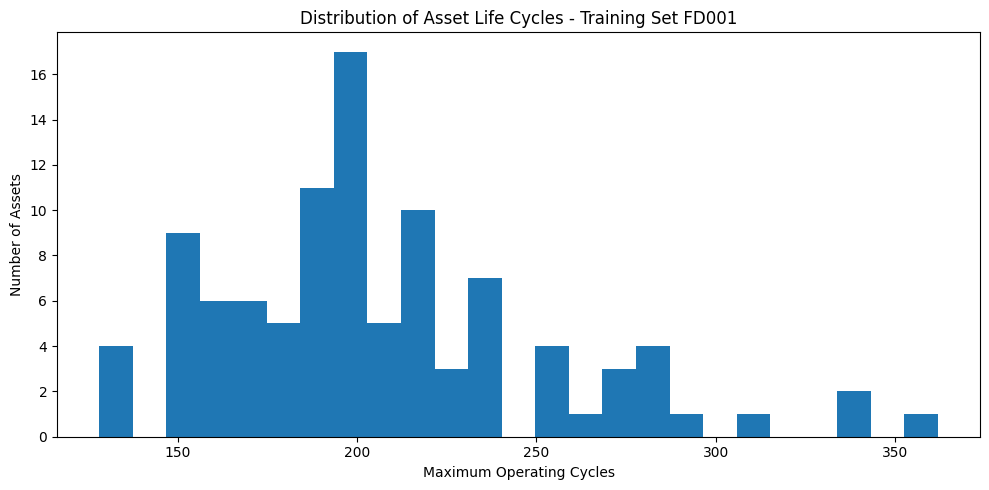

In [9]:
# ============================================================
# 2.7 ASSET LIFE CYCLE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(train_asset_cycles["max_cycles"], bins=25)

plt.title("Distribution of Asset Life Cycles - Training Set FD001")
plt.xlabel("Maximum Operating Cycles")
plt.ylabel("Number of Assets")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "01_asset_life_cycles_distribution.png", dpi=300)
plt.show()

# 3. Remaining Useful Life Target Engineering

The key target of predictive maintenance is the Remaining Useful Life.

For the training set, the RUL is computed as:

`RUL = maximum life cycle of asset - current cycle`

For the test set, the NASA dataset provides the true RUL at the last observed cycle of each asset. This allows us to reconstruct the RUL for each test row.

A capped RUL target is also created to reduce the effect of very large early-life values and improve model stability.

In [10]:
# ============================================================
# 3.1 TRAINING RUL TARGET CREATION
# ============================================================

train_data = train_fd001.copy()

# Maximum life cycle for each asset
max_cycles = train_data.groupby("unit_number")["time_in_cycles"].max().reset_index()
max_cycles.columns = ["unit_number", "max_cycle"]

# Merge max cycle into training data
train_data = train_data.merge(max_cycles, on="unit_number", how="left")

# Remaining Useful Life
train_data["RUL"] = train_data["max_cycle"] - train_data["time_in_cycles"]

# Capped RUL for more stable modeling
RUL_CAP = 125
train_data["RUL_capped"] = train_data["RUL"].clip(upper=RUL_CAP)

print("Training data with RUL created successfully")
print("Shape:", train_data.shape)

display(train_data[["unit_number", "time_in_cycles", "max_cycle", "RUL", "RUL_capped"]].head(10))

print("\nRUL summary:")
display(train_data["RUL"].describe())

print("\nCapped RUL summary:")
display(train_data["RUL_capped"].describe())

Training data with RUL created successfully
Shape: (20631, 29)


,unit_number,time_in_cycles,max_cycle,RUL,RUL_capped
0,1,1,192,191,125
1,1,2,192,190,125
2,1,3,192,189,125
3,1,4,192,188,125
4,1,5,192,187,125
5,1,6,192,186,125
6,1,7,192,185,125
7,1,8,192,184,125
8,1,9,192,183,125
9,1,10,192,182,125



RUL summary:


count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64


Capped RUL summary:


count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL_capped, dtype: float64

In [11]:
# ============================================================
# 3.2 TEST RUL TARGET CREATION
# ============================================================

test_data = test_fd001.copy()

# NASA RUL file gives the true RUL at the last observed cycle of each test asset
rul_test = rul_fd001.copy()
rul_test["unit_number"] = np.arange(1, len(rul_test) + 1)

# Last observed cycle in test set
last_cycles = test_data.groupby("unit_number")["time_in_cycles"].max().reset_index()
last_cycles.columns = ["unit_number", "last_observed_cycle"]

# Merge last cycle and true RUL
test_rul_info = last_cycles.merge(rul_test, on="unit_number", how="left")

# Estimated full life = last observed cycle + true RUL
test_rul_info["max_cycle"] = test_rul_info["last_observed_cycle"] + test_rul_info["true_rul"]

# Merge into test data
test_data = test_data.merge(
    test_rul_info[["unit_number", "max_cycle"]],
    on="unit_number",
    how="left"
)

# RUL for each test row
test_data["RUL"] = test_data["max_cycle"] - test_data["time_in_cycles"]
test_data["RUL_capped"] = test_data["RUL"].clip(upper=RUL_CAP)

print("Test data with RUL created successfully")
print("Shape:", test_data.shape)

display(test_data[["unit_number", "time_in_cycles", "max_cycle", "RUL", "RUL_capped"]].head(10))

print("\nTest RUL summary:")
display(test_data["RUL"].describe())

print("\nTest capped RUL summary:")
display(test_data["RUL_capped"].describe())

Test data with RUL created successfully
Shape: (13096, 29)


,unit_number,time_in_cycles,max_cycle,RUL,RUL_capped
0,1,1,143,142,125
1,1,2,143,141,125
2,1,3,143,140,125
3,1,4,143,139,125
4,1,5,143,138,125
5,1,6,143,137,125
6,1,7,143,136,125
7,1,8,143,135,125
8,1,9,143,134,125
9,1,10,143,133,125



Test RUL summary:


count    13096.000000
mean       141.238470
std         58.980114
min          7.000000
25%        102.000000
50%        140.000000
75%        179.000000
max        340.000000
Name: RUL, dtype: float64


Test capped RUL summary:


count    13096.000000
mean       108.919823
std         27.580258
min          7.000000
25%        102.000000
50%        125.000000
75%        125.000000
max        125.000000
Name: RUL_capped, dtype: float64

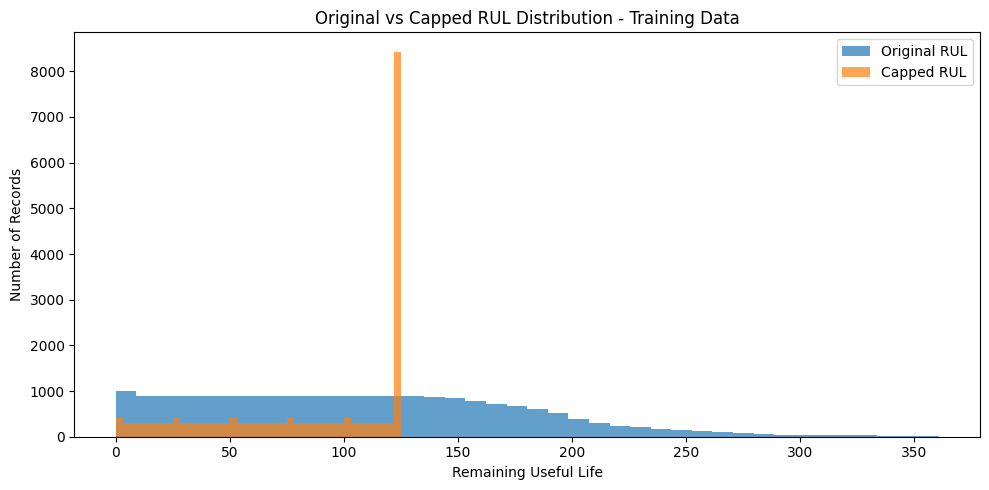

In [12]:
# ============================================================
# 3.3 RUL DISTRIBUTION VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(train_data["RUL"], bins=40, alpha=0.7, label="Original RUL")
plt.hist(train_data["RUL_capped"], bins=40, alpha=0.7, label="Capped RUL")

plt.title("Original vs Capped RUL Distribution - Training Data")
plt.xlabel("Remaining Useful Life")
plt.ylabel("Number of Records")
plt.legend()
plt.tight_layout()

plt.savefig(REPORTS_DIR / "02_rul_distribution.png", dpi=300)
plt.show()

## 3.4 Failure Risk Target

To make the model useful for industrial maintenance decisions, the numerical RUL target is converted into risk classes.

The risk levels are defined as:

- `Low Risk`: RUL greater than 80 cycles;
- `Medium Risk`: RUL between 41 and 80 cycles;
- `High Risk`: RUL between 16 and 40 cycles;
- `Critical Risk`: RUL less than or equal to 15 cycles.

This risk target will later be used for classification and maintenance priority scoring.

In [13]:
# ============================================================
# 3.4 FAILURE RISK TARGET CREATION
# ============================================================

def assign_failure_risk(rul):
    if rul <= 15:
        return "Critical Risk"
    elif rul <= 40:
        return "High Risk"
    elif rul <= 80:
        return "Medium Risk"
    else:
        return "Low Risk"


train_data["failure_risk"] = train_data["RUL"].apply(assign_failure_risk)
test_data["failure_risk"] = test_data["RUL"].apply(assign_failure_risk)

print("Training failure risk distribution:")
display(train_data["failure_risk"].value_counts())

print("\nTraining failure risk percentages:")
display((train_data["failure_risk"].value_counts(normalize=True) * 100).round(2))

print("\nTest failure risk distribution:")
display(test_data["failure_risk"].value_counts())

print("\nTest failure risk percentages:")
display((test_data["failure_risk"].value_counts(normalize=True) * 100).round(2))

Training failure risk distribution:


failure_risk
Low Risk         12531
Medium Risk       4000
High Risk         2500
Critical Risk     1600
Name: count, dtype: int64


Training failure risk percentages:


failure_risk
Low Risk         60.74
Medium Risk      19.39
High Risk        12.12
Critical Risk     7.76
Name: proportion, dtype: float64


Test failure risk distribution:


failure_risk
Low Risk         11016
Medium Risk       1484
High Risk          536
Critical Risk       60
Name: count, dtype: int64


Test failure risk percentages:


failure_risk
Low Risk         84.12
Medium Risk      11.33
High Risk         4.09
Critical Risk     0.46
Name: proportion, dtype: float64

In [14]:
# ============================================================
# 3.5 SAVE RUL-ENRICHED DATASETS
# ============================================================

train_output_path = PROCESSED_DATA_DIR / "fd001_train_with_rul.csv"
test_output_path = PROCESSED_DATA_DIR / "fd001_test_with_rul.csv"

train_data.to_csv(train_output_path, index=False)
test_data.to_csv(test_output_path, index=False)

print("Prepared training dataset saved at:", train_output_path)
print("Prepared test dataset saved at    :", test_output_path)

Prepared training dataset saved at: ..\data\processed\fd001_train_with_rul.csv
Prepared test dataset saved at    : ..\data\processed\fd001_test_with_rul.csv


# 4. Exploratory Data Analysis

This section analyzes the behavior of operational settings and sensor measurements.

The objective is to identify:

- constant or low-variance features;
- sensors correlated with Remaining Useful Life;
- degradation patterns over operating cycles;
- useful variables for predictive maintenance modeling.

This step is important because not all sensors provide useful degradation information.

In [15]:
# ============================================================
# 4.1 SENSOR AND OPERATIONAL SETTING SUMMARY
# ============================================================

feature_columns = setting_columns + sensor_columns

feature_summary = train_data[feature_columns].describe().T

feature_summary["range"] = feature_summary["max"] - feature_summary["min"]
feature_summary["unique_values"] = train_data[feature_columns].nunique()

feature_summary = feature_summary[
    ["mean", "std", "min", "max", "range", "unique_values"]
].sort_values(by="std")

display(feature_summary)

print("Feature summary created successfully")

,mean,std,min,max,range,unique_values
sensor_1,518.670000,0.000000e+00,518.6700,518.6700,0.0000,1
operational_setting_3,100.000000,0.000000e+00,100.0000,100.0000,0.0000,1
sensor_10,1.300000,0.000000e+00,1.3000,1.3000,0.0000,1
sensor_19,100.000000,0.000000e+00,100.0000,100.0000,0.0000,1
sensor_18,2388.000000,0.000000e+00,2388.0000,2388.0000,0.0000,1
sensor_16,0.030000,3.469531e-18,0.0300,0.0300,0.0000,1
sensor_5,14.620000,5.329200e-15,14.6200,14.6200,0.0000,1
operational_setting_2,0.000002,2.930621e-04,-0.0006,0.0006,0.0012,13
sensor_6,21.609803,1.388985e-03,21.6000,21.6100,0.0100,2
operational_setting_1,-0.000009,2.187313e-03,-0.0087,0.0087,0.0174,158


Feature summary created successfully


In [16]:
# ============================================================
# 4.2 CONSTANT AND LOW-VARIANCE FEATURES
# ============================================================

constant_features = [
    col for col in feature_columns
    if train_data[col].nunique() <= 1
]

low_variance_features = [
    col for col in feature_columns
    if train_data[col].std() < 1e-6
]

print("Number of constant features:", len(constant_features))
print(constant_features)

print("\nNumber of low-variance features:", len(low_variance_features))
print(low_variance_features)

Number of constant features: 7
['operational_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Number of low-variance features: 7
['operational_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [17]:
# ============================================================
# 4.3 CORRELATION WITH CAPPED RUL
# ============================================================

corr_with_rul = train_data[feature_columns + ["RUL_capped"]].corr(numeric_only=True)["RUL_capped"]

corr_with_rul = (
    corr_with_rul
    .drop("RUL_capped")
    .sort_values(key=abs, ascending=False)
)

corr_table = corr_with_rul.reset_index()
corr_table.columns = ["Feature", "Correlation_With_RUL_Capped"]

display(corr_table)

print("Top 10 features most correlated with capped RUL:")
display(corr_table.head(10))

,Feature,Correlation_With_RUL_Capped
0,sensor_11,-0.775230
1,sensor_4,-0.757157
2,sensor_12,0.748870
3,sensor_7,0.733021
4,sensor_15,-0.720858
5,sensor_21,0.707334
6,sensor_20,0.704626
7,sensor_17,-0.680829
8,sensor_2,-0.678458
9,sensor_3,-0.655030


Top 10 features most correlated with capped RUL:


,Feature,Correlation_With_RUL_Capped
0,sensor_11,-0.775230
1,sensor_4,-0.757157
2,sensor_12,0.748870
3,sensor_7,0.733021
4,sensor_15,-0.720858
5,sensor_21,0.707334
6,sensor_20,0.704626
7,sensor_17,-0.680829
8,sensor_2,-0.678458
9,sensor_3,-0.655030


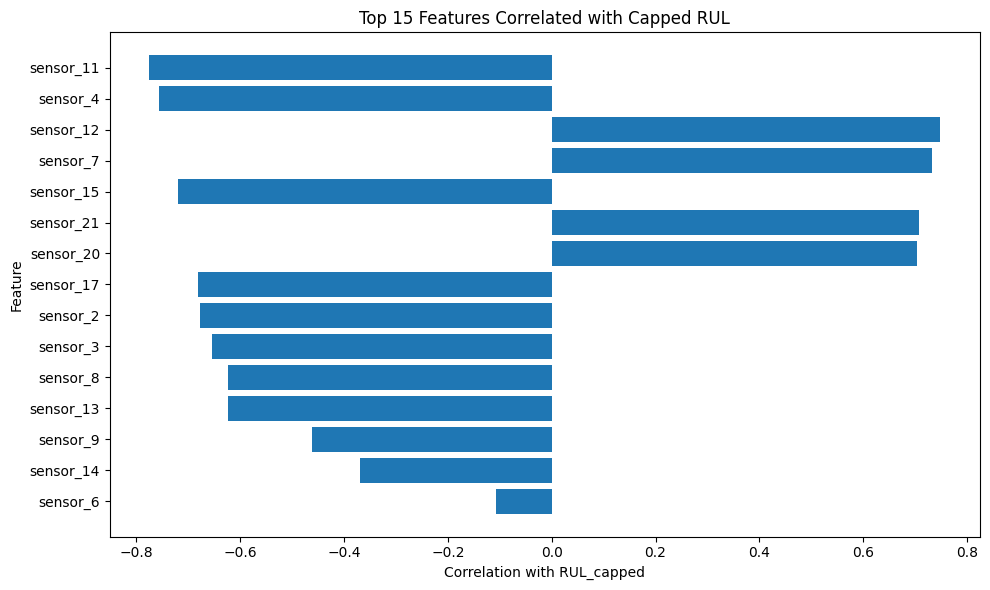

In [18]:
# ============================================================
# 4.4 CORRELATION VISUALIZATION
# ============================================================

top_corr = corr_table.head(15).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_corr["Feature"], top_corr["Correlation_With_RUL_Capped"])
plt.gca().invert_yaxis()

plt.title("Top 15 Features Correlated with Capped RUL")
plt.xlabel("Correlation with RUL_capped")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "03_top_rul_correlations.png", dpi=300)
plt.show()

In [19]:
# ============================================================
# 4.5 SELECT TOP SENSORS FOR DEGRADATION VISUALIZATION
# ============================================================

top_sensor_features = [
    feature for feature in corr_table["Feature"].tolist()
    if feature.startswith("sensor_")
][:6]

print("Top sensor features selected for degradation visualization:")
print(top_sensor_features)

Top sensor features selected for degradation visualization:
['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21']


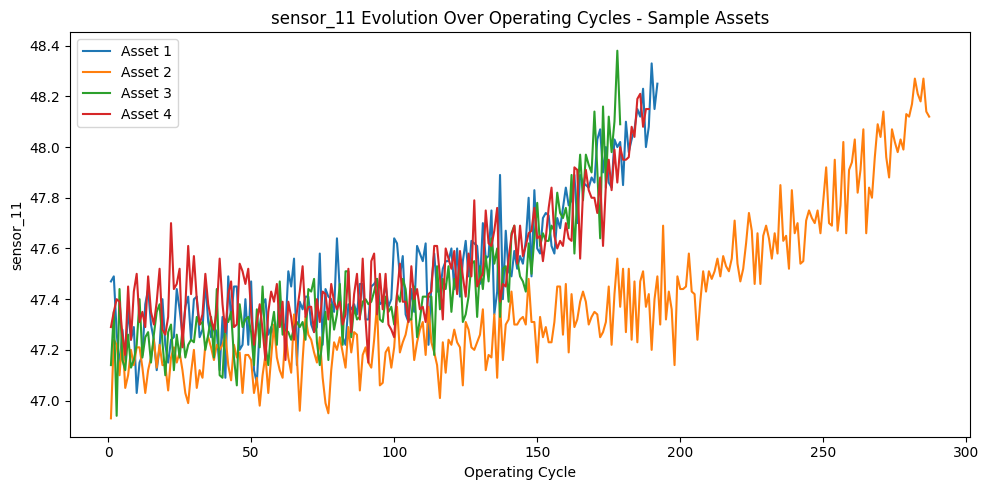

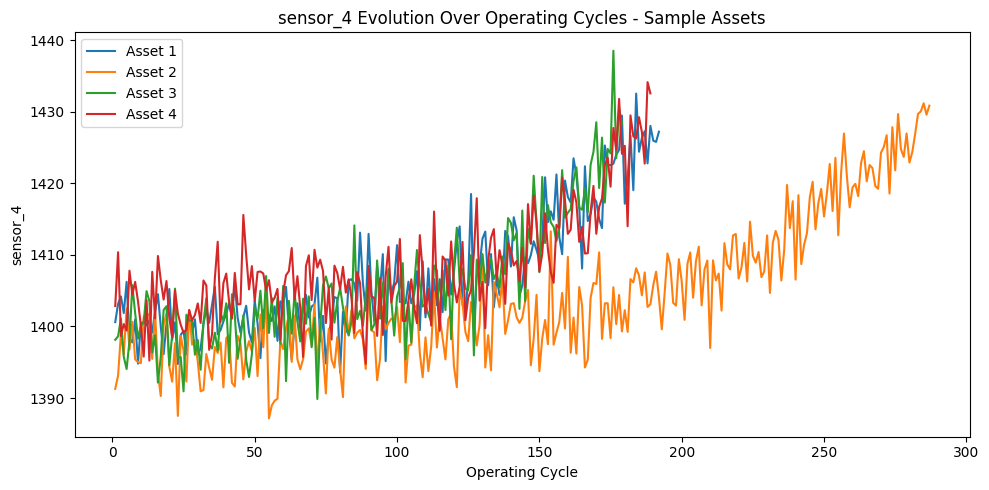

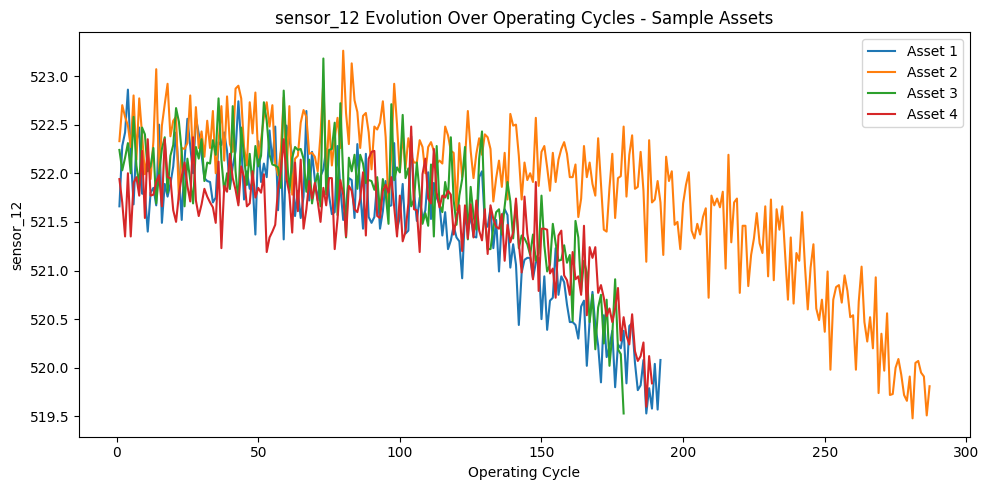

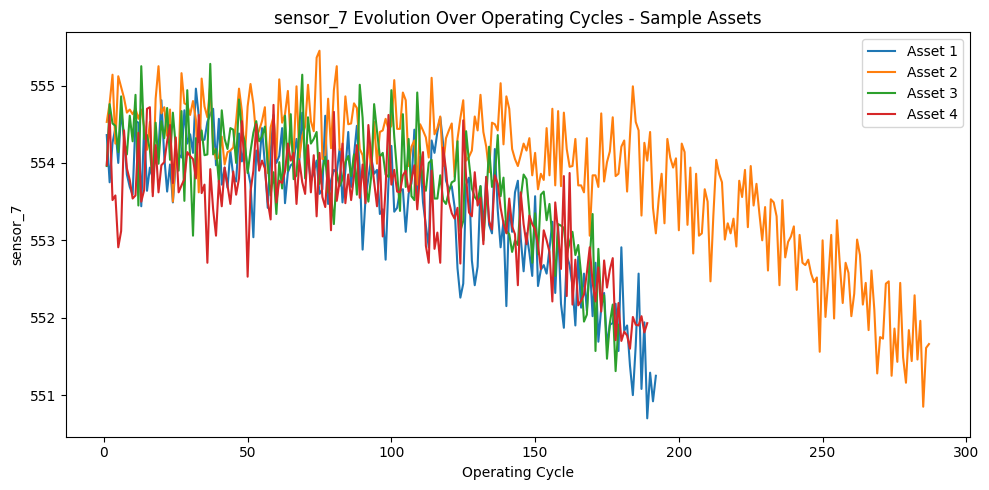

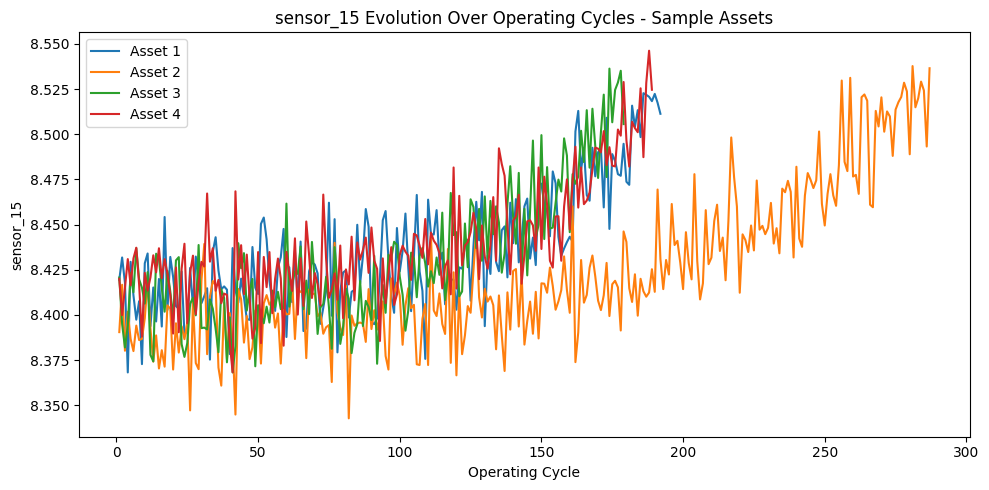

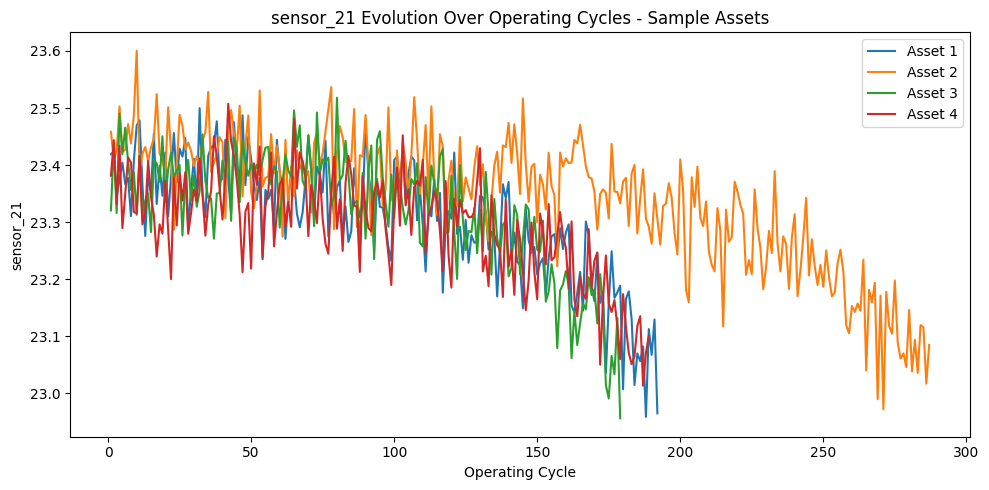

In [20]:
# ============================================================
# 4.6 SENSOR DEGRADATION TRAJECTORIES
# ============================================================

sample_units = [1, 2, 3, 4]

for sensor in top_sensor_features:
    plt.figure(figsize=(10, 5))
    
    for unit in sample_units:
        unit_data = train_data[train_data["unit_number"] == unit]
        
        plt.plot(
            unit_data["time_in_cycles"],
            unit_data[sensor],
            label=f"Asset {unit}"
        )
    
    plt.title(f"{sensor} Evolution Over Operating Cycles - Sample Assets")
    plt.xlabel("Operating Cycle")
    plt.ylabel(sensor)
    plt.legend()
    plt.tight_layout()
    
    plt.savefig(REPORTS_DIR / f"sensor_trend_{sensor}.png", dpi=300)
    plt.show()

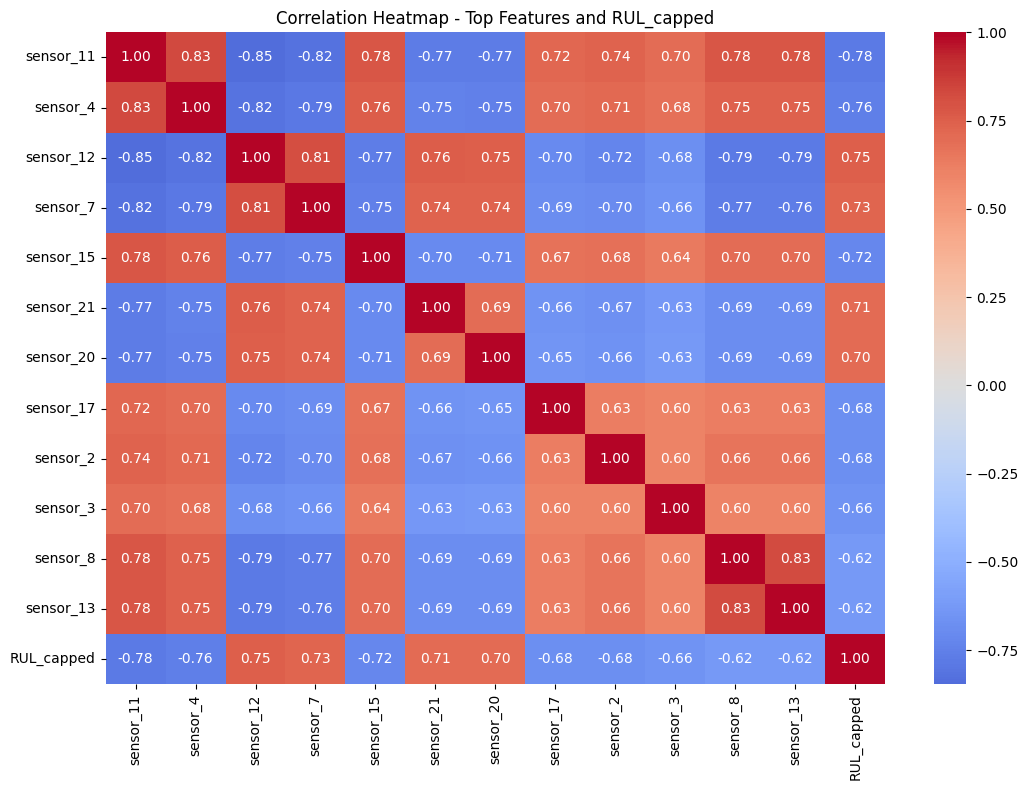

In [21]:
# ============================================================
# 4.7 CORRELATION HEATMAP OF TOP FEATURES
# ============================================================

top_features_for_heatmap = corr_table["Feature"].head(12).tolist() + ["RUL_capped"]

plt.figure(figsize=(11, 8))

sns.heatmap(
    train_data[top_features_for_heatmap].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap - Top Features and RUL_capped")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "04_top_features_correlation_heatmap.png", dpi=300)
plt.show()

# 5. Data Quality & Feature Selection

This section prepares the final candidate features for modeling.

Constant variables are removed because they do not provide predictive information.

Target-related columns such as `RUL`, `RUL_capped`, `failure_risk` and `max_cycle` are excluded to prevent data leakage.

The final feature set will be used to build robust Remaining Useful Life prediction models.

In [22]:
# ============================================================
# 5.1 FEATURE SELECTION WITHOUT DATA LEAKAGE
# ============================================================

# Columns that must never be used as input features
target_related_columns = [
    "max_cycle",
    "RUL",
    "RUL_capped",
    "failure_risk"
]

identifier_columns = [
    "unit_number"
]

# Features removed because they are constant
features_to_remove = sorted(set(constant_features))

# Candidate original features
candidate_original_features = [
    "time_in_cycles"
] + [
    col for col in feature_columns
    if col not in features_to_remove
]

# Safety check: remove any leakage column if accidentally included
candidate_original_features = [
    col for col in candidate_original_features
    if col not in target_related_columns + identifier_columns
]

print("Number of original features before removing constants:", len(["time_in_cycles"] + feature_columns))
print("Number of constant features removed:", len(features_to_remove))
print("Number of candidate original features:", len(candidate_original_features))

print("\nRemoved constant features:")
print(features_to_remove)

print("\nCandidate original features:")
print(candidate_original_features)

Number of original features before removing constants: 25
Number of constant features removed: 7
Number of candidate original features: 18

Removed constant features:
['operational_setting_3', 'sensor_1', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'sensor_5']

Candidate original features:
['time_in_cycles', 'operational_setting_1', 'operational_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [23]:
# ============================================================
# 5.2 DATA LEAKAGE CHECK
# ============================================================

forbidden_columns = target_related_columns + identifier_columns

leakage_found = [
    col for col in candidate_original_features
    if col in forbidden_columns
]

print("Forbidden columns:", forbidden_columns)
print("Leakage columns found in candidate features:", leakage_found)

if len(leakage_found) == 0:
    print("✅ No data leakage detected in candidate original features")
else:
    print("⚠️ Data leakage detected. Please review feature list.")

Forbidden columns: ['max_cycle', 'RUL', 'RUL_capped', 'failure_risk', 'unit_number']
Leakage columns found in candidate features: []
✅ No data leakage detected in candidate original features


# 6. Industrial Feature Engineering

This section creates industrial maintenance-oriented features.

The objective is to transform raw sensor values into interpretable health indicators.

The engineered features are created using only current-cycle information and training-set statistics, which avoids future leakage.

Key engineered indicators include:

- `degradation_index`: global degradation signal;
- `asset_health_score`: interpretable health score between 0 and 100;
- `thermal_stress_index`: stress signal from sensors that increase with degradation;
- `efficiency_loss_index`: loss signal from sensors that decrease with degradation;
- `cycle_log`: logarithmic transformation of operating cycle;
- `cycle_ratio`: normalized operating age;
- `operational_setting_magnitude`: global operating condition magnitude.

In [24]:
# ============================================================
# 6.1 IDENTIFY INFORMATIVE DEGRADATION SENSORS
# ============================================================

corr_clean = corr_table.dropna().copy()

# Keep only sensor variables with meaningful correlation
CORR_THRESHOLD = 0.10

informative_sensor_features = [
    row["Feature"]
    for _, row in corr_clean.iterrows()
    if row["Feature"].startswith("sensor_")
    and abs(row["Correlation_With_RUL_Capped"]) >= CORR_THRESHOLD
    and row["Feature"] not in features_to_remove
]

corr_lookup = dict(
    zip(corr_clean["Feature"], corr_clean["Correlation_With_RUL_Capped"])
)

sensors_increase_with_degradation = [
    sensor for sensor in informative_sensor_features
    if corr_lookup[sensor] < 0
]

sensors_decrease_with_degradation = [
    sensor for sensor in informative_sensor_features
    if corr_lookup[sensor] > 0
]

print("Number of informative sensors:", len(informative_sensor_features))
print("\nInformative sensors:")
print(informative_sensor_features)

print("\nSensors that increase when degradation increases:")
print(sensors_increase_with_degradation)

print("\nSensors that decrease when degradation increases:")
print(sensors_decrease_with_degradation)

Number of informative sensors: 15

Informative sensors:
['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21', 'sensor_20', 'sensor_17', 'sensor_2', 'sensor_3', 'sensor_8', 'sensor_13', 'sensor_9', 'sensor_14', 'sensor_6']

Sensors that increase when degradation increases:
['sensor_11', 'sensor_4', 'sensor_15', 'sensor_17', 'sensor_2', 'sensor_3', 'sensor_8', 'sensor_13', 'sensor_9', 'sensor_14', 'sensor_6']

Sensors that decrease when degradation increases:
['sensor_12', 'sensor_7', 'sensor_21', 'sensor_20']


In [25]:
# ============================================================
# 6.2 INDUSTRIAL FEATURE ENGINEERING FUNCTION
# ============================================================

def fit_engineering_reference(train_df, sensor_list):
    """
    Compute reference statistics from training data only.
    These statistics will be reused on both train and test data.
    """
    reference = {}
    
    for sensor in sensor_list:
        mean_value = train_df[sensor].mean()
        std_value = train_df[sensor].std()
        
        if std_value == 0 or pd.isna(std_value):
            std_value = 1.0
        
        reference[sensor] = {
            "mean": mean_value,
            "std": std_value
        }
    
    reference["cycle_max"] = train_df["time_in_cycles"].max()
    
    return reference


def add_industrial_features(df, reference_stats, corr_lookup, informative_sensors):
    """
    Add industrial maintenance-oriented features using current sensor values.
    No target information is used.
    """
    engineered_df = df.copy()
    
    degradation_components = []
    thermal_components = []
    efficiency_components = []
    
    for sensor in informative_sensors:
        mean_value = reference_stats[sensor]["mean"]
        std_value = reference_stats[sensor]["std"]
        
        z_sensor = (engineered_df[sensor] - mean_value) / std_value
        
        # If correlation with RUL is negative:
        # sensor increases when degradation increases
        if corr_lookup[sensor] < 0:
            degradation_signal = z_sensor
            thermal_components.append(degradation_signal)
        
        # If correlation with RUL is positive:
        # sensor decreases when degradation increases
        else:
            degradation_signal = -z_sensor
            efficiency_components.append(degradation_signal)
        
        degradation_components.append(degradation_signal)
    
    # Global degradation index
    engineered_df["degradation_index"] = np.vstack(
        [component.to_numpy() for component in degradation_components]
    ).mean(axis=0)
    
    # Thermal stress index
    if len(thermal_components) > 0:
        engineered_df["thermal_stress_index"] = np.vstack(
            [component.to_numpy() for component in thermal_components]
        ).mean(axis=0)
    else:
        engineered_df["thermal_stress_index"] = 0
    
    # Efficiency loss index
    if len(efficiency_components) > 0:
        engineered_df["efficiency_loss_index"] = np.vstack(
            [component.to_numpy() for component in efficiency_components]
        ).mean(axis=0)
    else:
        engineered_df["efficiency_loss_index"] = 0
    
    # Cycle-based features
    engineered_df["cycle_log"] = np.log1p(engineered_df["time_in_cycles"])
    engineered_df["cycle_ratio"] = engineered_df["time_in_cycles"] / reference_stats["cycle_max"]
    
    # Operational setting magnitude
    engineered_df["operational_setting_magnitude"] = np.sqrt(
        engineered_df["operational_setting_1"] ** 2
        + engineered_df["operational_setting_2"] ** 2
    )
    
    return engineered_df

In [26]:
# ============================================================
# 6.3 APPLY INDUSTRIAL FEATURE ENGINEERING
# ============================================================

engineering_reference = fit_engineering_reference(
    train_data,
    informative_sensor_features
)

train_engineered = add_industrial_features(
    train_data,
    engineering_reference,
    corr_lookup,
    informative_sensor_features
)

test_engineered = add_industrial_features(
    test_data,
    engineering_reference,
    corr_lookup,
    informative_sensor_features
)

print("Train engineered shape:", train_engineered.shape)
print("Test engineered shape :", test_engineered.shape)

new_engineered_features = [
    "degradation_index",
    "thermal_stress_index",
    "efficiency_loss_index",
    "cycle_log",
    "cycle_ratio",
    "operational_setting_magnitude"
]

display(train_engineered[new_engineered_features].head())

print("\nEngineered feature summary:")
display(train_engineered[new_engineered_features].describe().T)


Train engineered shape: (20631, 36)
Test engineered shape : (13096, 36)


,degradation_index,thermal_stress_index,efficiency_loss_index,cycle_log,cycle_ratio,operational_setting_magnitude
0,-0.733160,-0.636288,-0.999556,0.693147,0.002762,0.000806
1,-0.614993,-0.487701,-0.965046,1.098612,0.005525,0.001924
2,-0.738394,-0.678164,-0.904025,1.386294,0.008287,0.004310
3,-0.829594,-0.739045,-1.078604,1.609438,0.011050,0.000700
4,-0.603513,-0.523882,-0.822498,1.791759,0.013812,0.001910



Engineered feature summary:


,count,mean,std,min,25%,50%,75%,max
degradation_index,20631.0,-2.005817e-15,0.740119,-1.869285,-0.531392,-0.097569,0.403395,3.359090
thermal_stress_index,20631.0,-1.377622e-16,0.701668,-1.880391,-0.487390,-0.098475,0.369288,3.872203
efficiency_loss_index,20631.0,-7.218737e-15,0.900556,-2.175948,-0.670123,-0.093145,0.534978,3.005680
cycle_log,20631.0,4.396209e+00,0.931490,0.693147,3.970292,4.653960,5.056246,5.894403
cycle_ratio,20631.0,3.005742e-01,0.190279,0.002762,0.143646,0.287293,0.430939,1.000000
operational_setting_magnitude,20631.0,1.791467e-03,0.001289,0.000000,0.000762,0.001503,0.002518,0.008714


In [27]:
# ============================================================
# 6.4 ASSET HEALTH SCORE
# ============================================================

# Use training percentiles to scale health score
deg_p05 = train_engineered["degradation_index"].quantile(0.05)
deg_p95 = train_engineered["degradation_index"].quantile(0.95)

def add_asset_health_score(df, p05, p95):
    result = df.copy()
    
    result["asset_health_score"] = 100 * (
        1 - (result["degradation_index"] - p05) / (p95 - p05)
    )
    
    result["asset_health_score"] = result["asset_health_score"].clip(0, 100)
    
    return result


train_engineered = add_asset_health_score(train_engineered, deg_p05, deg_p95)
test_engineered = add_asset_health_score(test_engineered, deg_p05, deg_p95)

new_engineered_features.append("asset_health_score")

print("Asset health score created successfully")

print("\nTraining health score summary:")
display(train_engineered["asset_health_score"].describe())

print("\nAverage health score by failure risk:")
display(
    train_engineered.groupby("failure_risk")["asset_health_score"]
    .mean()
    .sort_values(ascending=False)
)

Asset health score created successfully

Training health score summary:


count    20631.000000
mean        59.027168
std         27.820379
min          0.000000
25%         42.612715
50%         62.765163
75%         80.216710
max        100.000000
Name: asset_health_score, dtype: float64


Average health score by failure risk:


failure_risk
Low Risk         75.247407
Medium Risk      51.496322
High Risk        25.541555
Critical Risk     3.140666
Name: asset_health_score, dtype: float64

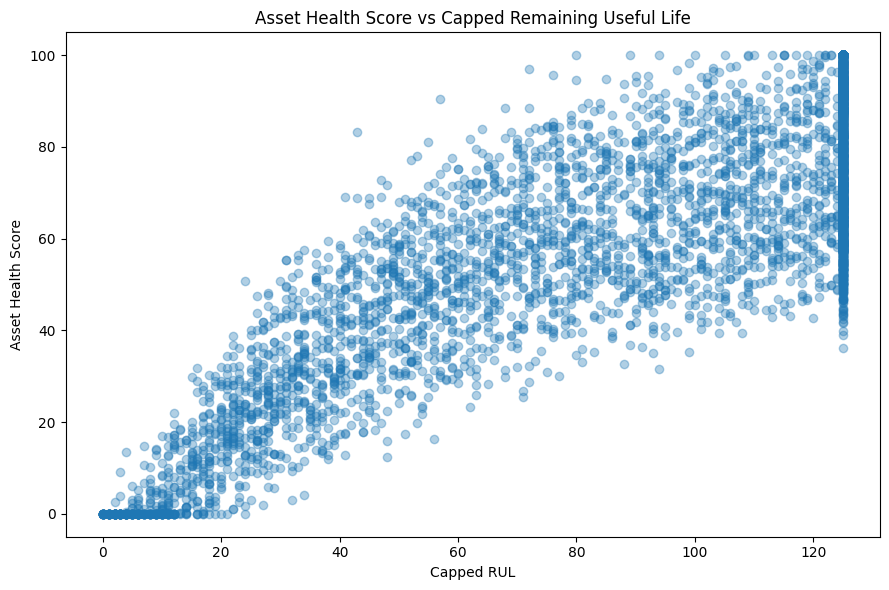

In [28]:
# ============================================================
# 6.5 HEALTH SCORE VS RUL VISUALIZATION
# ============================================================

sample_plot = train_engineered.sample(
    n=min(5000, len(train_engineered)),
    random_state=42
)

plt.figure(figsize=(9, 6))

plt.scatter(
    sample_plot["RUL_capped"],
    sample_plot["asset_health_score"],
    alpha=0.35
)

plt.title("Asset Health Score vs Capped Remaining Useful Life")
plt.xlabel("Capped RUL")
plt.ylabel("Asset Health Score")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "05_health_score_vs_rul.png", dpi=300)
plt.show()

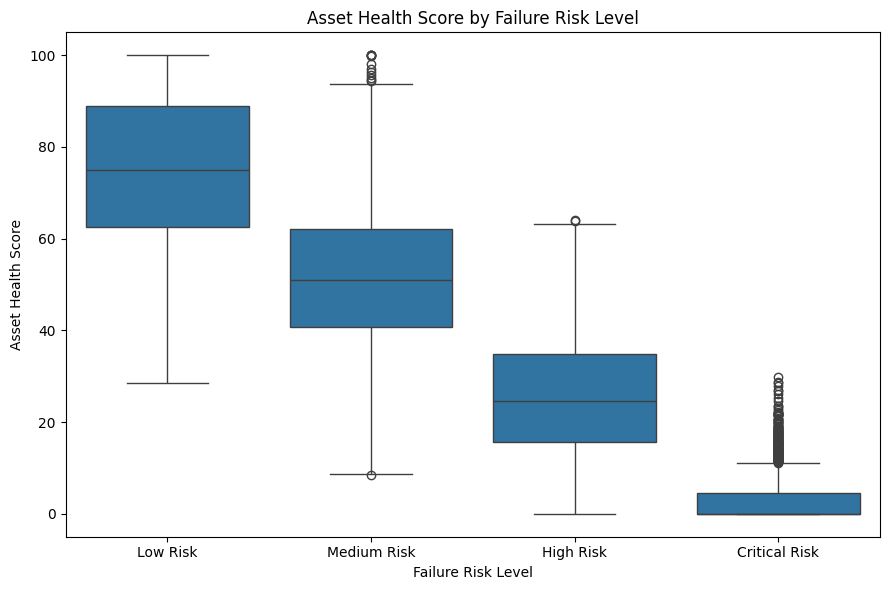

In [29]:
# ============================================================
# 6.6 HEALTH SCORE BY FAILURE RISK
# ============================================================

risk_order = ["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=train_engineered,
    x="failure_risk",
    y="asset_health_score",
    order=risk_order
)

plt.title("Asset Health Score by Failure Risk Level")
plt.xlabel("Failure Risk Level")
plt.ylabel("Asset Health Score")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "06_health_score_by_failure_risk.png", dpi=300)
plt.show()

In [30]:
# ============================================================
# 6.7 FINAL FEATURE LIST FOR MODELING
# ============================================================

final_feature_columns = candidate_original_features + new_engineered_features

# Final safety check
final_feature_columns = [
    col for col in final_feature_columns
    if col not in target_related_columns + identifier_columns
]

print("Number of final model features:", len(final_feature_columns))

print("\nFinal model features:")
print(final_feature_columns)

X_train_full = train_engineered[final_feature_columns].copy()
y_train_rul = train_engineered["RUL_capped"].copy()

X_test_full = test_engineered[final_feature_columns].copy()
y_test_rul = test_engineered["RUL_capped"].copy()

print("\nX_train_full shape:", X_train_full.shape)
print("y_train_rul shape :", y_train_rul.shape)
print("X_test_full shape :", X_test_full.shape)
print("y_test_rul shape  :", y_test_rul.shape)

print("\nMissing values in X_train:", X_train_full.isnull().sum().sum())
print("Missing values in X_test :", X_test_full.isnull().sum().sum())

print("\nInfinite values in X_train:", np.isinf(X_train_full).sum().sum())
print("Infinite values in X_test :", np.isinf(X_test_full).sum().sum())

Number of final model features: 25

Final model features:
['time_in_cycles', 'operational_setting_1', 'operational_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'degradation_index', 'thermal_stress_index', 'efficiency_loss_index', 'cycle_log', 'cycle_ratio', 'operational_setting_magnitude', 'asset_health_score']

X_train_full shape: (20631, 25)
y_train_rul shape : (20631,)
X_test_full shape : (13096, 25)
y_test_rul shape  : (13096,)

Missing values in X_train: 0
Missing values in X_test : 0

Infinite values in X_train: 0
Infinite values in X_test : 0


In [31]:
# ============================================================
# 6.8 SAVE ENGINEERED DATASETS
# ============================================================

train_engineered_path = PROCESSED_DATA_DIR / "fd001_train_engineered.csv"
test_engineered_path = PROCESSED_DATA_DIR / "fd001_test_engineered.csv"

train_engineered.to_csv(train_engineered_path, index=False)
test_engineered.to_csv(test_engineered_path, index=False)

print("Engineered training dataset saved at:", train_engineered_path)
print("Engineered test dataset saved at    :", test_engineered_path)

Engineered training dataset saved at: ..\data\processed\fd001_train_engineered.csv
Engineered test dataset saved at    : ..\data\processed\fd001_test_engineered.csv


# 7. Train-Validation Split by Equipment

To avoid data leakage and overly optimistic validation results, the train-validation split is performed by asset.

This means that all cycles of the same `unit_number` are kept either in the training set or in the validation set.

This validation strategy better evaluates the model's ability to generalize to unseen industrial assets.

In [32]:
# ============================================================
# 7.1 TRAIN-VALIDATION SPLIT BY EQUIPMENT
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

groups = train_engineered["unit_number"]

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, val_idx = next(
    group_split.split(
        train_engineered[final_feature_columns],
        train_engineered["RUL_capped"],
        groups=groups
    )
)

train_model_data = train_engineered.iloc[train_idx].copy()
val_model_data = train_engineered.iloc[val_idx].copy()

X_train = train_model_data[final_feature_columns].copy()
y_train = train_model_data["RUL_capped"].copy()

X_val = val_model_data[final_feature_columns].copy()
y_val = val_model_data["RUL_capped"].copy()

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)

print("\nNumber of training assets:", train_model_data["unit_number"].nunique())
print("Number of validation assets:", val_model_data["unit_number"].nunique())

print("\nTraining asset IDs:")
print(sorted(train_model_data["unit_number"].unique())[:20], "...")

print("\nValidation asset IDs:")
print(sorted(val_model_data["unit_number"].unique()))

print("\nRUL distribution in training set:")
display(y_train.describe())

print("\nRUL distribution in validation set:")
display(y_val.describe())

Training set shape: (16561, 25)
Validation set shape: (4070, 25)

Number of training assets: 80
Number of validation assets: 20

Training asset IDs:
[np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(20), np.int64(21), np.int64(22), np.int64(24), np.int64(25), np.int64(26)] ...

Validation asset IDs:
[np.int64(1), np.int64(5), np.int64(11), np.int64(13), np.int64(19), np.int64(23), np.int64(31), np.int64(32), np.int64(34), np.int64(40), np.int64(45), np.int64(46), np.int64(54), np.int64(71), np.int64(74), np.int64(77), np.int64(78), np.int64(81), np.int64(84), np.int64(91)]

RUL distribution in training set:


count    16561.000000
mean        86.958819
std         41.662359
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL_capped, dtype: float64


RUL distribution in validation set:


count    4070.000000
mean       86.302211
std        41.720784
min         0.000000
25%        50.000000
50%       101.000000
75%       125.000000
max       125.000000
Name: RUL_capped, dtype: float64

In [33]:
# ============================================================
# 7.2 GROUP LEAKAGE CHECK
# ============================================================

train_units = set(train_model_data["unit_number"].unique())
val_units = set(val_model_data["unit_number"].unique())

overlap_units = train_units.intersection(val_units)

print("Number of overlapping assets between train and validation:", len(overlap_units))

if len(overlap_units) == 0:
    print("✅ No asset leakage detected between train and validation sets")
else:
    print("⚠️ Asset leakage detected:")
    print(overlap_units)

Number of overlapping assets between train and validation: 0
✅ No asset leakage detected between train and validation sets


In [34]:
# ============================================================
# 7.3 SIMPLE BASELINE MODEL
# ============================================================

baseline_prediction = np.full(shape=len(y_val), fill_value=y_train.mean())

baseline_mae = mean_absolute_error(y_val, baseline_prediction)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_prediction))
baseline_r2 = r2_score(y_val, baseline_prediction)

baseline_results = pd.DataFrame({
    "Model": ["Baseline Mean Predictor"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2]
})

display(baseline_results)

,Model,MAE,RMSE,R2
0,Baseline Mean Predictor,36.929803,41.720825,-0.000248


# 8. Remaining Useful Life Regression Models

This section trains several regression models to predict capped Remaining Useful Life.

The objective is not only to obtain good scores, but also to verify generalization using the asset-level validation split.

Models will be compared using:

- MAE: average prediction error in cycles;
- RMSE: penalizes large errors;
- R²: proportion of variance explained by the model.

In [35]:
# ============================================================
# 8.1 MODEL IMPORTS
# ============================================================

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import time

print("Regression models imported successfully")

Regression models imported successfully


In [36]:
# ============================================================
# 8.2 DEFINE REGRESSION MODELS
# ============================================================

regression_models = {
    "Ridge Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=250,
        max_depth=18,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),
    
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=250,
        max_depth=18,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    )
}

print("Regression models defined successfully")
print(list(regression_models.keys()))

Regression models defined successfully
['Ridge Regression', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'HistGradientBoosting']


In [37]:
# ============================================================
# 8.3 TRAIN AND EVALUATE REGRESSION MODELS
# ============================================================

regression_results = []
trained_regression_models = {}

for model_name, model in regression_models.items():
    print(f"Training model: {model_name}")
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_pred = np.clip(train_pred, 0, RUL_CAP)
    val_pred = np.clip(val_pred, 0, RUL_CAP)
    
    train_mae = mean_absolute_error(y_train, train_pred)
    val_mae = mean_absolute_error(y_val, val_pred)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    
    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)
    
    training_time = time.time() - start_time
    
    regression_results.append({
        "Model": model_name,
        "Train MAE": train_mae,
        "Validation MAE": val_mae,
        "MAE Gap": val_mae - train_mae,
        "Train RMSE": train_rmse,
        "Validation RMSE": val_rmse,
        "Train R2": train_r2,
        "Validation R2": val_r2,
        "R2 Gap": train_r2 - val_r2,
        "Training Time Seconds": training_time
    })
    
    trained_regression_models[model_name] = model
    
    print(
        f"{model_name} completed | "
        f"Val MAE={val_mae:.2f} | "
        f"Val RMSE={val_rmse:.2f} | "
        f"Val R2={val_r2:.3f}"
    )

regression_results_df = pd.DataFrame(regression_results)
regression_results_df = regression_results_df.sort_values(by="Validation MAE")

display(regression_results_df)

Training model: Ridge Regression
Ridge Regression completed | Val MAE=12.80 | Val RMSE=17.12 | Val R2=0.832
Training model: Random Forest
Random Forest completed | Val MAE=10.71 | Val RMSE=16.00 | Val R2=0.853
Training model: Extra Trees
Extra Trees completed | Val MAE=10.67 | Val RMSE=15.93 | Val R2=0.854
Training model: Gradient Boosting
Gradient Boosting completed | Val MAE=10.48 | Val RMSE=15.31 | Val R2=0.865
Training model: HistGradientBoosting
HistGradientBoosting completed | Val MAE=10.69 | Val RMSE=15.72 | Val R2=0.858


,Model,Train MAE,Validation MAE,MAE Gap,Train RMSE,Validation RMSE,Train R2,Validation R2,R2 Gap,Training Time Seconds
3,Gradient Boosting,10.418528,10.483701,0.065173,15.272862,15.310966,0.865606,0.865288,0.000318,27.264276
2,Extra Trees,4.321506,10.672617,6.351110,6.793296,15.928011,0.973411,0.854211,0.119200,6.813088
4,HistGradientBoosting,9.627082,10.694563,1.067481,13.932714,15.721568,0.888157,0.857966,0.030191,4.336046
1,Random Forest,5.272905,10.709285,5.436381,8.030837,15.999143,0.962841,0.852906,0.109935,33.942755
0,Ridge Regression,14.837586,12.802619,-2.034967,19.473676,17.115224,0.781509,0.831668,-0.050159,0.100973


## 8.4 Final Model Evaluation on External Test Set

The best validation model is evaluated on the external FD001 test set.

This test set contains assets that were not used during training.

Two evaluations are performed:

1. all available test cycles;
2. last observed cycle of each asset, which represents the most realistic deployment scenario.

The objective is to verify generalization before exporting the model to the FastAPI service.

In [38]:
# ============================================================
# 8.4 FINAL MODEL SELECTION
# ============================================================

best_regression_model_name = "Gradient Boosting"
best_regression_model = trained_regression_models[best_regression_model_name]

print("Selected final RUL regression model:", best_regression_model_name)

Selected final RUL regression model: Gradient Boosting


In [39]:
# ============================================================
# 8.5 EXTERNAL TEST EVALUATION - ALL TEST CYCLES
# ============================================================

test_pred_all = best_regression_model.predict(X_test_full)
test_pred_all = np.clip(test_pred_all, 0, RUL_CAP)

test_all_mae = mean_absolute_error(y_test_rul, test_pred_all)
test_all_rmse = np.sqrt(mean_squared_error(y_test_rul, test_pred_all))
test_all_r2 = r2_score(y_test_rul, test_pred_all)

external_test_results_all = pd.DataFrame({
    "Evaluation": ["External Test - All Cycles"],
    "MAE": [test_all_mae],
    "RMSE": [test_all_rmse],
    "R2": [test_all_r2]
})

display(external_test_results_all)

,Evaluation,MAE,RMSE,R2
0,External Test - All Cycles,9.937586,15.471968,0.685278


In [40]:
# ============================================================
# 8.6 EXTERNAL TEST EVALUATION - LAST OBSERVED CYCLE ONLY
# ============================================================

last_cycle_idx = (
    test_engineered
    .groupby("unit_number")["time_in_cycles"]
    .idxmax()
)

test_last_cycle_data = test_engineered.loc[last_cycle_idx].copy()

X_test_last = test_last_cycle_data[final_feature_columns].copy()
y_test_last = test_last_cycle_data["RUL_capped"].copy()

test_pred_last = best_regression_model.predict(X_test_last)
test_pred_last = np.clip(test_pred_last, 0, RUL_CAP)

test_last_mae = mean_absolute_error(y_test_last, test_pred_last)
test_last_rmse = np.sqrt(mean_squared_error(y_test_last, test_pred_last))
test_last_r2 = r2_score(y_test_last, test_pred_last)

external_test_results_last = pd.DataFrame({
    "Evaluation": ["External Test - Last Cycle per Asset"],
    "MAE": [test_last_mae],
    "RMSE": [test_last_rmse],
    "R2": [test_last_r2]
})

display(external_test_results_last)

print("Number of test assets evaluated:", test_last_cycle_data["unit_number"].nunique())

,Evaluation,MAE,RMSE,R2
0,External Test - Last Cycle per Asset,11.543262,16.093308,0.83872


Number of test assets evaluated: 100


In [41]:
# ============================================================
# 8.7 FINAL REGRESSION RESULTS SUMMARY
# ============================================================

final_regression_summary = pd.concat(
    [
        baseline_results.rename(columns={
            "Model": "Evaluation"
        }),
        pd.DataFrame({
            "Evaluation": ["Validation - Asset Split"],
            "MAE": [regression_results_df.loc[regression_results_df["Model"] == best_regression_model_name, "Validation MAE"].values[0]],
            "RMSE": [regression_results_df.loc[regression_results_df["Model"] == best_regression_model_name, "Validation RMSE"].values[0]],
            "R2": [regression_results_df.loc[regression_results_df["Model"] == best_regression_model_name, "Validation R2"].values[0]]
        }),
        external_test_results_all,
        external_test_results_last
    ],
    ignore_index=True
)

display(final_regression_summary)

final_regression_summary.to_csv(
    PROCESSED_DATA_DIR / "rul_regression_results_summary.csv",
    index=False
)

print("Final regression summary saved successfully")

,Evaluation,MAE,RMSE,R2
0,Baseline Mean Predictor,36.929803,41.720825,-0.000248
1,Validation - Asset Split,10.483701,15.310966,0.865288
2,External Test - All Cycles,9.937586,15.471968,0.685278
3,External Test - Last Cycle per Asset,11.543262,16.093308,0.838720


Final regression summary saved successfully


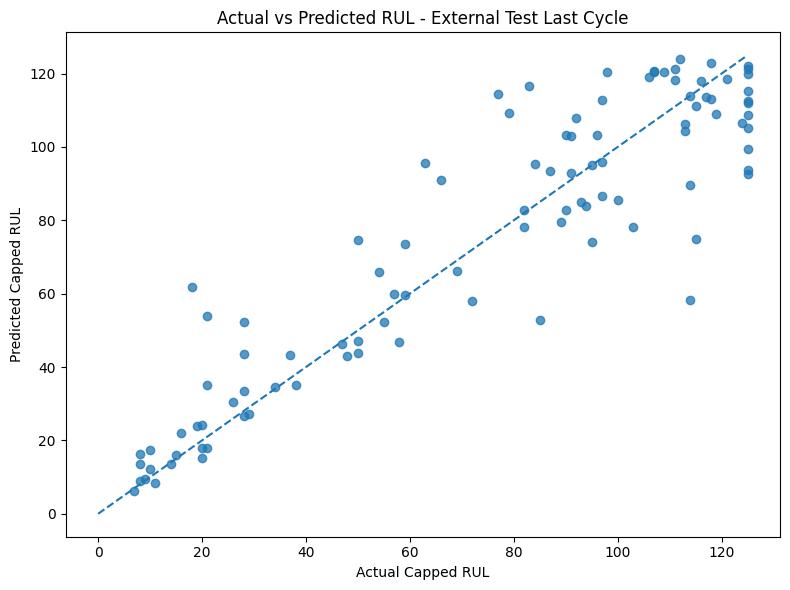

In [42]:
# ============================================================
# 8.8 ACTUAL VS PREDICTED RUL VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_last,
    test_pred_last,
    alpha=0.75
)

plt.plot(
    [0, RUL_CAP],
    [0, RUL_CAP],
    linestyle="--"
)

plt.title("Actual vs Predicted RUL - External Test Last Cycle")
plt.xlabel("Actual Capped RUL")
plt.ylabel("Predicted Capped RUL")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "07_actual_vs_predicted_rul_test.png", dpi=300)
plt.show()

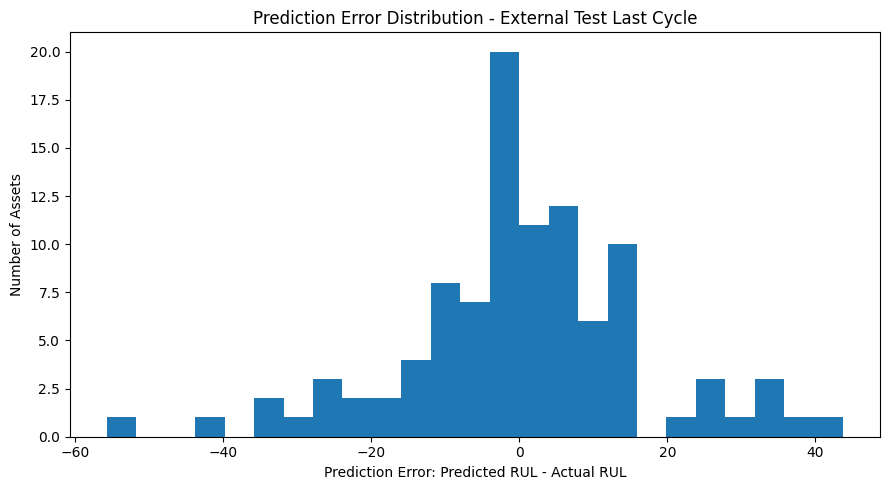

Prediction error summary:


count    100.000000
mean       0.390106
std       16.169630
min      -55.696727
25%       -6.817068
50%       -0.210910
75%        8.734813
max       43.761208
Name: prediction_error, dtype: float64

In [43]:
# ============================================================
# 8.9 PREDICTION ERROR ANALYSIS
# ============================================================

test_last_cycle_data["predicted_RUL"] = test_pred_last
test_last_cycle_data["prediction_error"] = (
    test_last_cycle_data["predicted_RUL"] - test_last_cycle_data["RUL_capped"]
)

plt.figure(figsize=(9, 5))

plt.hist(test_last_cycle_data["prediction_error"], bins=25)

plt.title("Prediction Error Distribution - External Test Last Cycle")
plt.xlabel("Prediction Error: Predicted RUL - Actual RUL")
plt.ylabel("Number of Assets")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "08_prediction_error_distribution.png", dpi=300)
plt.show()

print("Prediction error summary:")
display(test_last_cycle_data["prediction_error"].describe())

## 8.10 Risk-Level Error Analysis

The final regression model is evaluated by failure risk level.

This step is important because predictive maintenance systems must be especially reliable for high-risk and critical assets.

A model may have a good global MAE while still performing poorly on critical equipment. Therefore, errors are analyzed separately for each risk category.

In [44]:
# ============================================================
# 8.10 ERROR ANALYSIS BY FAILURE RISK LEVEL
# ============================================================

test_last_cycle_data["absolute_error"] = np.abs(
    test_last_cycle_data["predicted_RUL"] - test_last_cycle_data["RUL_capped"]
)

risk_error_summary = (
    test_last_cycle_data
    .groupby("failure_risk")
    .agg(
        Assets=("unit_number", "count"),
        Mean_Actual_RUL=("RUL_capped", "mean"),
        Mean_Predicted_RUL=("predicted_RUL", "mean"),
        MAE=("absolute_error", "mean"),
        Median_Error=("absolute_error", "median"),
        Max_Error=("absolute_error", "max")
    )
    .reindex(["Low Risk", "Medium Risk", "High Risk", "Critical Risk"])
)

display(risk_error_summary)

,Assets,Mean_Actual_RUL,Mean_Predicted_RUL,MAE,Median_Error,Max_Error
failure_risk,,,,,,
Low Risk,55,106.909091,102.101478,13.112174,10.428512,55.696727
Medium Risk,17,59.588235,67.499964,13.256208,11.289505,37.330604
High Risk,18,25.111111,33.273758,9.913305,4.901135,43.761208
Critical Risk,10,10.000000,12.200228,2.936158,1.513501,8.199889


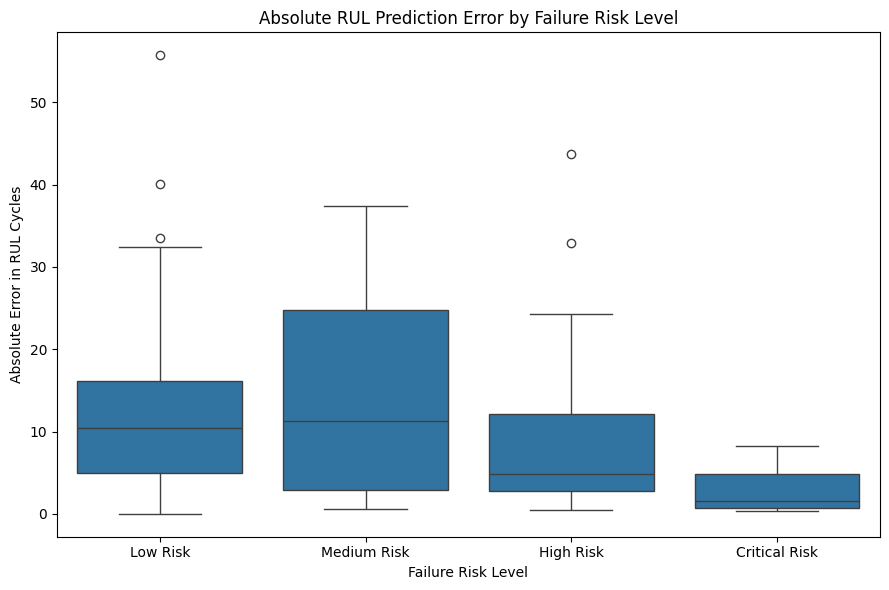

In [45]:
# ============================================================
# 8.11 ERROR DISTRIBUTION BY FAILURE RISK
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=test_last_cycle_data,
    x="failure_risk",
    y="absolute_error",
    order=["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]
)

plt.title("Absolute RUL Prediction Error by Failure Risk Level")
plt.xlabel("Failure Risk Level")
plt.ylabel("Absolute Error in RUL Cycles")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "09_error_by_failure_risk.png", dpi=300)
plt.show()

In [46]:
# ============================================================
# 8.12 SAVE EXTERNAL TEST PREDICTIONS
# ============================================================

test_predictions_output = test_last_cycle_data[
    [
        "unit_number",
        "time_in_cycles",
        "RUL",
        "RUL_capped",
        "predicted_RUL",
        "prediction_error",
        "absolute_error",
        "failure_risk",
        "asset_health_score",
        "degradation_index"
    ]
].copy()

test_predictions_output.to_csv(
    PROCESSED_DATA_DIR / "external_test_last_cycle_predictions.csv",
    index=False
)

print("External test predictions saved successfully")
display(test_predictions_output.head())

External test predictions saved successfully


,unit_number,time_in_cycles,RUL,RUL_capped,predicted_RUL,prediction_error,absolute_error,failure_risk,asset_health_score,degradation_index
30,1,31,112,112,123.888463,11.888463,11.888463,Low Risk,83.444936,-0.611641
79,2,49,98,98,120.362300,22.362300,22.362300,Low Risk,68.077642,-0.229630
205,3,126,69,69,66.154065,-2.845935,2.845935,Medium Risk,46.887564,0.297128
311,4,106,82,82,82.882501,0.882501,0.882501,Low Risk,47.618689,0.278953
409,5,98,91,91,92.787382,1.787382,1.787382,Low Risk,59.750519,-0.022629


# 9. Failure Risk Classification & Maintenance Priority

The regression model predicts Remaining Useful Life.

For industrial decision-making, this numerical prediction is converted into a maintenance risk level.

The predicted RUL is mapped into four risk categories:

- Low Risk;
- Medium Risk;
- High Risk;
- Critical Risk.

Then, each risk level is translated into a maintenance priority and an operational recommendation.

This is the layer that transforms the machine learning model into a business decision-support system.

In [47]:
# ============================================================
# 9.1 BUSINESS DECISION FUNCTIONS
# ============================================================

def assign_failure_risk_from_rul(rul):
    """
    Convert predicted Remaining Useful Life into failure risk level.
    """
    if rul <= 15:
        return "Critical Risk"
    elif rul <= 40:
        return "High Risk"
    elif rul <= 80:
        return "Medium Risk"
    else:
        return "Low Risk"


def assign_maintenance_priority(failure_risk):
    """
    Convert failure risk level into maintenance priority.
    """
    if failure_risk == "Critical Risk":
        return "Immediate Intervention"
    elif failure_risk == "High Risk":
        return "Urgent Maintenance"
    elif failure_risk == "Medium Risk":
        return "Planned Inspection"
    else:
        return "Normal Monitoring"


def assign_recommendation(failure_risk):
    """
    Generate operational recommendation for maintenance teams.
    """
    if failure_risk == "Critical Risk":
        return "Immediate shutdown inspection or emergency maintenance is recommended."
    elif failure_risk == "High Risk":
        return "Schedule urgent maintenance within the next operational window."
    elif failure_risk == "Medium Risk":
        return "Plan inspection and increase monitoring frequency."
    else:
        return "Continue normal monitoring under standard maintenance schedule."


print("Business decision functions defined successfully")

Business decision functions defined successfully


In [48]:
# ============================================================
# 9.2 APPLY FAILURE RISK CLASSIFICATION ON EXTERNAL TEST
# ============================================================

risk_predictions = test_last_cycle_data.copy()

risk_predictions["predicted_failure_risk"] = risk_predictions["predicted_RUL"].apply(
    assign_failure_risk_from_rul
)

risk_predictions["maintenance_priority"] = risk_predictions["predicted_failure_risk"].apply(
    assign_maintenance_priority
)

risk_predictions["recommendation"] = risk_predictions["predicted_failure_risk"].apply(
    assign_recommendation
)

display(
    risk_predictions[
        [
            "unit_number",
            "RUL_capped",
            "predicted_RUL",
            "failure_risk",
            "predicted_failure_risk",
            "maintenance_priority",
            "recommendation"
        ]
    ].head(10)
)

,unit_number,RUL_capped,predicted_RUL,failure_risk,predicted_failure_risk,maintenance_priority,recommendation
30,1,112,123.888463,Low Risk,Low Risk,Normal Monitoring,Continue normal monitoring under standard main...
79,2,98,120.362300,Low Risk,Low Risk,Normal Monitoring,Continue normal monitoring under standard main...
205,3,69,66.154065,Medium Risk,Medium Risk,Planned Inspection,Plan inspection and increase monitoring freque...
311,4,82,82.882501,Low Risk,Low Risk,Normal Monitoring,Continue normal monitoring under standard main...
409,5,91,92.787382,Low Risk,Low Risk,Normal Monitoring,Continue normal monitoring under standard main...
514,6,93,84.999899,Low Risk,Low Risk,Normal Monitoring,Continue normal monitoring under standard main...
674,7,91,103.034206,Low Risk,Low Risk,Normal Monitoring,Continue normal monitoring under standard main...
840,8,95,74.074215,Low Risk,Medium Risk,Planned Inspection,Plan inspection and increase monitoring freque...
895,9,111,118.353288,Low Risk,Low Risk,Normal Monitoring,Continue normal monitoring under standard main...
1087,10,96,103.390289,Low Risk,Low Risk,Normal Monitoring,Continue normal monitoring under standard main...


In [50]:
# ============================================================
# 9.3 TRUE VS PREDICTED RISK DISTRIBUTION
# ============================================================

risk_order = ["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]

true_risk_distribution = (
    risk_predictions["failure_risk"]
    .value_counts()
    .reindex(risk_order)
    .fillna(0)
    .astype(int)
)

predicted_risk_distribution = (
    risk_predictions["predicted_failure_risk"]
    .value_counts()
    .reindex(risk_order)
    .fillna(0)
    .astype(int)
)

risk_distribution_table = pd.DataFrame({
    "True Risk Count": true_risk_distribution,
    "Predicted Risk Count": predicted_risk_distribution
})

display(risk_distribution_table)

,True Risk Count,Predicted Risk Count
Low Risk,55,52
Medium Risk,17,25
High Risk,18,16
Critical Risk,10,7


In [51]:
# ============================================================
# 9.4 FAILURE RISK CLASSIFICATION METRICS
# ============================================================

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

y_true_risk = risk_predictions["failure_risk"]
y_pred_risk = risk_predictions["predicted_failure_risk"]

risk_accuracy = accuracy_score(y_true_risk, y_pred_risk)
risk_precision_weighted = precision_score(
    y_true_risk, y_pred_risk, average="weighted", zero_division=0
)
risk_recall_weighted = recall_score(
    y_true_risk, y_pred_risk, average="weighted", zero_division=0
)
risk_f1_weighted = f1_score(
    y_true_risk, y_pred_risk, average="weighted", zero_division=0
)

risk_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Weighted Precision", "Weighted Recall", "Weighted F1-score"],
    "Value": [
        risk_accuracy,
        risk_precision_weighted,
        risk_recall_weighted,
        risk_f1_weighted
    ]
})

display(risk_metrics)

print("Classification report:")
print(
    classification_report(
        y_true_risk,
        y_pred_risk,
        labels=risk_order,
        zero_division=0
    )
)

,Metric,Value
0,Accuracy,0.810000
1,Weighted Precision,0.842342
2,Weighted Recall,0.810000
3,Weighted F1-score,0.818696


Classification report:
               precision    recall  f1-score   support

     Low Risk       0.92      0.87      0.90        55
  Medium Risk       0.52      0.76      0.62        17
    High Risk       0.81      0.72      0.76        18
Critical Risk       1.00      0.70      0.82        10

     accuracy                           0.81       100
    macro avg       0.81      0.76      0.78       100
 weighted avg       0.84      0.81      0.82       100



,Pred Low Risk,Pred Medium Risk,Pred High Risk,Pred Critical Risk
True Low Risk,48,7,0,0
True Medium Risk,4,13,0,0
True High Risk,0,5,13,0
True Critical Risk,0,0,3,7


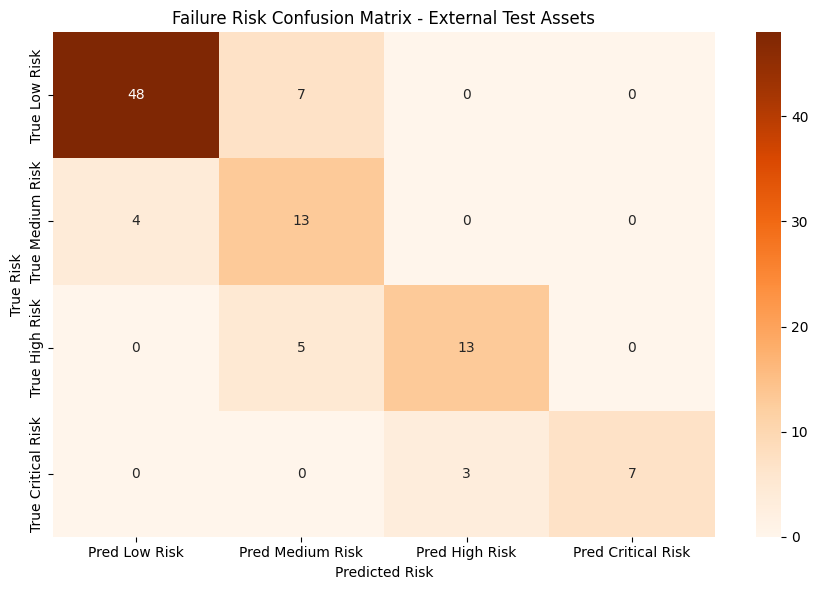

In [52]:
# ============================================================
# 9.5 FAILURE RISK CONFUSION MATRIX
# ============================================================

risk_cm = confusion_matrix(
    y_true_risk,
    y_pred_risk,
    labels=risk_order
)

risk_cm_df = pd.DataFrame(
    risk_cm,
    index=[f"True {label}" for label in risk_order],
    columns=[f"Pred {label}" for label in risk_order]
)

display(risk_cm_df)

plt.figure(figsize=(9, 6))

sns.heatmap(
    risk_cm_df,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Failure Risk Confusion Matrix - External Test Assets")
plt.xlabel("Predicted Risk")
plt.ylabel("True Risk")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "10_failure_risk_confusion_matrix.png", dpi=300)
plt.show()

In [53]:
# ============================================================
# 9.6 DANGEROUS MISCLASSIFICATION AUDIT
# ============================================================

risk_severity_map = {
    "Low Risk": 1,
    "Medium Risk": 2,
    "High Risk": 3,
    "Critical Risk": 4
}

risk_predictions["true_risk_score"] = risk_predictions["failure_risk"].map(risk_severity_map)
risk_predictions["predicted_risk_score"] = risk_predictions["predicted_failure_risk"].map(risk_severity_map)

risk_predictions["risk_error_direction"] = (
    risk_predictions["predicted_risk_score"] - risk_predictions["true_risk_score"]
)

dangerous_underestimations = risk_predictions[
    risk_predictions["risk_error_direction"] <= -2
].copy()

minor_underestimations = risk_predictions[
    risk_predictions["risk_error_direction"] == -1
].copy()

overestimations = risk_predictions[
    risk_predictions["risk_error_direction"] > 0
].copy()

print("Dangerous underestimations count:", len(dangerous_underestimations))
print("Minor underestimations count    :", len(minor_underestimations))
print("Overestimations count           :", len(overestimations))

if len(dangerous_underestimations) > 0:
    display(
        dangerous_underestimations[
            [
                "unit_number",
                "RUL_capped",
                "predicted_RUL",
                "failure_risk",
                "predicted_failure_risk",
                "absolute_error"
            ]
        ]
    )
else:
    print("✅ No dangerous risk underestimation detected.")

Dangerous underestimations count: 0
Minor underestimations count    : 12
Overestimations count           : 7
✅ No dangerous risk underestimation detected.


In [54]:
# ============================================================
# 9.7 SAVE FAILURE RISK SCORING RESULTS
# ============================================================

risk_scoring_output = risk_predictions[
    [
        "unit_number",
        "time_in_cycles",
        "RUL",
        "RUL_capped",
        "predicted_RUL",
        "failure_risk",
        "predicted_failure_risk",
        "maintenance_priority",
        "recommendation",
        "asset_health_score",
        "degradation_index",
        "absolute_error"
    ]
].copy()

risk_scoring_output.to_csv(
    PROCESSED_DATA_DIR / "failure_risk_scoring_results.csv",
    index=False
)

risk_metrics.to_csv(
    PROCESSED_DATA_DIR / "failure_risk_classification_metrics.csv",
    index=False
)

risk_cm_df.to_csv(
    PROCESSED_DATA_DIR / "failure_risk_confusion_matrix.csv"
)

print("Failure risk scoring results saved successfully")
print("Files saved in:", PROCESSED_DATA_DIR)

Failure risk scoring results saved successfully
Files saved in: ..\data\processed


# 10. Business Threshold Calibration

The regression model predicts Remaining Useful Life.

Risk classes are created using business thresholds.

In industrial maintenance, it is often better to use conservative thresholds to avoid underestimating high-risk assets.

This section compares several threshold strategies and selects the safest one for deployment.

In [55]:
# ============================================================
# 10.1 DEFINE BUSINESS THRESHOLD STRATEGIES
# ============================================================

threshold_strategies = {
    "Standard": {
        "critical": 15,
        "high": 40,
        "medium": 80
    },
    
    "Conservative_1": {
        "critical": 20,
        "high": 45,
        "medium": 85
    },
    
    "Conservative_2": {
        "critical": 25,
        "high": 50,
        "medium": 90
    },
    
    "Very_Conservative": {
        "critical": 30,
        "high": 55,
        "medium": 95
    }
}


def assign_failure_risk_with_thresholds(rul, thresholds):
    if rul <= thresholds["critical"]:
        return "Critical Risk"
    elif rul <= thresholds["high"]:
        return "High Risk"
    elif rul <= thresholds["medium"]:
        return "Medium Risk"
    else:
        return "Low Risk"


print("Threshold strategies defined successfully")

for name, thresholds in threshold_strategies.items():
    print(name, thresholds)

Threshold strategies defined successfully
Standard {'critical': 15, 'high': 40, 'medium': 80}
Conservative_1 {'critical': 20, 'high': 45, 'medium': 85}
Conservative_2 {'critical': 25, 'high': 50, 'medium': 90}
Very_Conservative {'critical': 30, 'high': 55, 'medium': 95}


In [56]:
# ============================================================
# 10.2 EVALUATE THRESHOLD STRATEGIES
# ============================================================

threshold_results = []

risk_order = ["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]

for strategy_name, thresholds in threshold_strategies.items():
    temp_df = risk_predictions.copy()
    
    temp_df["calibrated_predicted_risk"] = temp_df["predicted_RUL"].apply(
        lambda x: assign_failure_risk_with_thresholds(x, thresholds)
    )
    
    y_true = temp_df["failure_risk"]
    y_pred = temp_df["calibrated_predicted_risk"]
    
    accuracy = accuracy_score(y_true, y_pred)
    weighted_precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    weighted_recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    
    temp_df["true_risk_score"] = temp_df["failure_risk"].map(risk_severity_map)
    temp_df["predicted_risk_score"] = temp_df["calibrated_predicted_risk"].map(risk_severity_map)
    temp_df["risk_error_direction"] = temp_df["predicted_risk_score"] - temp_df["true_risk_score"]
    
    dangerous_underestimations = (temp_df["risk_error_direction"] <= -2).sum()
    minor_underestimations = (temp_df["risk_error_direction"] == -1).sum()
    overestimations = (temp_df["risk_error_direction"] > 0).sum()
    
    critical_recall = recall_score(
        y_true == "Critical Risk",
        y_pred == "Critical Risk",
        zero_division=0
    )
    
    high_or_critical_true = y_true.isin(["High Risk", "Critical Risk"])
    high_or_critical_pred = y_pred.isin(["High Risk", "Critical Risk"])
    
    high_critical_recall = recall_score(
        high_or_critical_true,
        high_or_critical_pred,
        zero_division=0
    )
    
    threshold_results.append({
        "Strategy": strategy_name,
        "Critical Threshold": thresholds["critical"],
        "High Threshold": thresholds["high"],
        "Medium Threshold": thresholds["medium"],
        "Accuracy": accuracy,
        "Weighted Precision": weighted_precision,
        "Weighted Recall": weighted_recall,
        "Weighted F1": weighted_f1,
        "Critical Recall": critical_recall,
        "High/Critical Recall": high_critical_recall,
        "Dangerous Underestimations": dangerous_underestimations,
        "Minor Underestimations": minor_underestimations,
        "Overestimations": overestimations
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(threshold_results_df)

,Strategy,Critical Threshold,High Threshold,Medium Threshold,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Critical Recall,High/Critical Recall,Dangerous Underestimations,Minor Underestimations,Overestimations
0,Standard,15,40,80,0.81,0.842342,0.81,0.818696,0.7,0.821429,0,12,7
1,Conservative_1,20,45,85,0.77,0.810175,0.77,0.780907,1.0,0.892857,0,7,16
2,Conservative_2,25,50,90,0.68,0.733725,0.68,0.693935,1.0,0.892857,0,7,25
3,Very_Conservative,30,55,95,0.64,0.717863,0.64,0.658400,1.0,0.964286,0,4,32


In [57]:
# ============================================================
# 10.3 SELECT BEST BUSINESS THRESHOLD STRATEGY
# ============================================================

safe_threshold_results = threshold_results_df[
    threshold_results_df["Dangerous Underestimations"] == 0
].copy()

safe_threshold_results = safe_threshold_results.sort_values(
    by=["High/Critical Recall", "Weighted F1"],
    ascending=[False, False]
)

best_threshold_strategy_name = safe_threshold_results.iloc[0]["Strategy"]

best_thresholds = threshold_strategies[best_threshold_strategy_name]

print("Selected threshold strategy:", best_threshold_strategy_name)
print("Selected thresholds:", best_thresholds)

display(safe_threshold_results)

Selected threshold strategy: Very_Conservative
Selected thresholds: {'critical': 30, 'high': 55, 'medium': 95}


,Strategy,Critical Threshold,High Threshold,Medium Threshold,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Critical Recall,High/Critical Recall,Dangerous Underestimations,Minor Underestimations,Overestimations
3,Very_Conservative,30,55,95,0.64,0.717863,0.64,0.658400,1.0,0.964286,0,4,32
1,Conservative_1,20,45,85,0.77,0.810175,0.77,0.780907,1.0,0.892857,0,7,16
2,Conservative_2,25,50,90,0.68,0.733725,0.68,0.693935,1.0,0.892857,0,7,25
0,Standard,15,40,80,0.81,0.842342,0.81,0.818696,0.7,0.821429,0,12,7


In [58]:
# ============================================================
# 10.4 APPLY SELECTED THRESHOLD STRATEGY
# ============================================================

risk_predictions["final_predicted_failure_risk"] = risk_predictions["predicted_RUL"].apply(
    lambda x: assign_failure_risk_with_thresholds(x, best_thresholds)
)

risk_predictions["final_maintenance_priority"] = risk_predictions["final_predicted_failure_risk"].apply(
    assign_maintenance_priority
)

risk_predictions["final_recommendation"] = risk_predictions["final_predicted_failure_risk"].apply(
    assign_recommendation
)

display(
    risk_predictions[
        [
            "unit_number",
            "RUL_capped",
            "predicted_RUL",
            "failure_risk",
            "predicted_failure_risk",
            "final_predicted_failure_risk",
            "final_maintenance_priority"
        ]
    ].head(15)
)

,unit_number,RUL_capped,predicted_RUL,failure_risk,predicted_failure_risk,final_predicted_failure_risk,final_maintenance_priority
30,1,112,123.888463,Low Risk,Low Risk,Low Risk,Normal Monitoring
79,2,98,120.362300,Low Risk,Low Risk,Low Risk,Normal Monitoring
205,3,69,66.154065,Medium Risk,Medium Risk,Medium Risk,Planned Inspection
311,4,82,82.882501,Low Risk,Low Risk,Medium Risk,Planned Inspection
409,5,91,92.787382,Low Risk,Low Risk,Medium Risk,Planned Inspection
514,6,93,84.999899,Low Risk,Low Risk,Medium Risk,Planned Inspection
674,7,91,103.034206,Low Risk,Low Risk,Low Risk,Normal Monitoring
840,8,95,74.074215,Low Risk,Medium Risk,Medium Risk,Planned Inspection
895,9,111,118.353288,Low Risk,Low Risk,Low Risk,Normal Monitoring
1087,10,96,103.390289,Low Risk,Low Risk,Low Risk,Normal Monitoring


,Pred Low Risk,Pred Medium Risk,Pred High Risk,Pred Critical Risk
True Low Risk,37,17,1,0
True Medium Risk,3,8,6,0
True High Risk,0,1,9,8
True Critical Risk,0,0,0,10


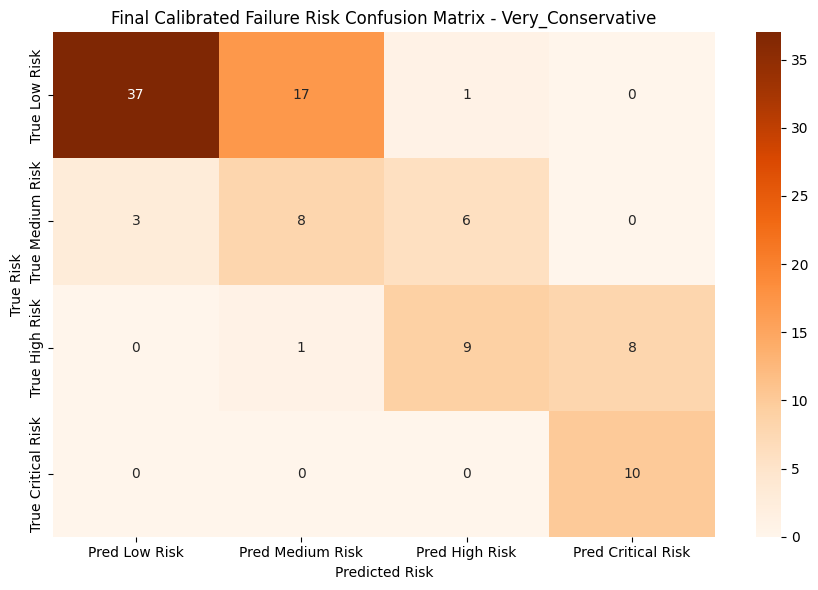

Final classification report:
               precision    recall  f1-score   support

     Low Risk       0.93      0.67      0.78        55
  Medium Risk       0.31      0.47      0.37        17
    High Risk       0.56      0.50      0.53        18
Critical Risk       0.56      1.00      0.71        10

     accuracy                           0.64       100
    macro avg       0.59      0.66      0.60       100
 weighted avg       0.72      0.64      0.66       100



In [59]:
# ============================================================
# 10.5 FINAL CALIBRATED CONFUSION MATRIX
# ============================================================

y_true_final = risk_predictions["failure_risk"]
y_pred_final = risk_predictions["final_predicted_failure_risk"]

final_risk_cm = confusion_matrix(
    y_true_final,
    y_pred_final,
    labels=risk_order
)

final_risk_cm_df = pd.DataFrame(
    final_risk_cm,
    index=[f"True {label}" for label in risk_order],
    columns=[f"Pred {label}" for label in risk_order]
)

display(final_risk_cm_df)

plt.figure(figsize=(9, 6))

sns.heatmap(
    final_risk_cm_df,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title(f"Final Calibrated Failure Risk Confusion Matrix - {best_threshold_strategy_name}")
plt.xlabel("Predicted Risk")
plt.ylabel("True Risk")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "11_final_calibrated_failure_risk_confusion_matrix.png", dpi=300)
plt.show()

print("Final classification report:")
print(
    classification_report(
        y_true_final,
        y_pred_final,
        labels=risk_order,
        zero_division=0
    )
)

In [60]:
# ============================================================
# 10.6 SAVE FINAL THRESHOLD STRATEGY
# ============================================================

final_thresholds_df = pd.DataFrame({
    "Selected_Strategy": [best_threshold_strategy_name],
    "Critical_Threshold": [best_thresholds["critical"]],
    "High_Threshold": [best_thresholds["high"]],
    "Medium_Threshold": [best_thresholds["medium"]]
})

final_thresholds_df.to_csv(
    PROCESSED_DATA_DIR / "final_business_thresholds.csv",
    index=False
)

threshold_results_df.to_csv(
    PROCESSED_DATA_DIR / "threshold_strategy_comparison.csv",
    index=False
)

final_risk_cm_df.to_csv(
    PROCESSED_DATA_DIR / "final_calibrated_failure_risk_confusion_matrix.csv"
)

print("Final thresholds saved successfully")
display(final_thresholds_df)

Final thresholds saved successfully


,Selected_Strategy,Critical_Threshold,High_Threshold,Medium_Threshold
0,Very_Conservative,30,55,95


In [61]:
# ============================================================
# 10.7 FINAL BUSINESS STRATEGY OVERRIDE
# ============================================================

# The automatic selection favored the safest strategy.
# However, for deployment we select Conservative_1 as the best business compromise:
# - 100% Critical Risk recall
# - 0 dangerous underestimations
# - better global F1-score and fewer false alarms than Very_Conservative

best_threshold_strategy_name = "Conservative_1"
best_thresholds = threshold_strategies[best_threshold_strategy_name]

print("Final selected business threshold strategy:", best_threshold_strategy_name)
print("Final selected thresholds:", best_thresholds)

risk_predictions["final_predicted_failure_risk"] = risk_predictions["predicted_RUL"].apply(
    lambda x: assign_failure_risk_with_thresholds(x, best_thresholds)
)

risk_predictions["final_maintenance_priority"] = risk_predictions["final_predicted_failure_risk"].apply(
    assign_maintenance_priority
)

risk_predictions["final_recommendation"] = risk_predictions["final_predicted_failure_risk"].apply(
    assign_recommendation
)

y_true_final = risk_predictions["failure_risk"]
y_pred_final = risk_predictions["final_predicted_failure_risk"]

final_accuracy = accuracy_score(y_true_final, y_pred_final)
final_precision = precision_score(y_true_final, y_pred_final, average="weighted", zero_division=0)
final_recall = recall_score(y_true_final, y_pred_final, average="weighted", zero_division=0)
final_f1 = f1_score(y_true_final, y_pred_final, average="weighted", zero_division=0)

final_risk_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Weighted Precision", "Weighted Recall", "Weighted F1-score"],
    "Value": [final_accuracy, final_precision, final_recall, final_f1]
})

display(final_risk_metrics)

print("Final classification report:")
print(
    classification_report(
        y_true_final,
        y_pred_final,
        labels=risk_order,
        zero_division=0
    )
)

Final selected business threshold strategy: Conservative_1
Final selected thresholds: {'critical': 20, 'high': 45, 'medium': 85}


,Metric,Value
0,Accuracy,0.770000
1,Weighted Precision,0.810175
2,Weighted Recall,0.770000
3,Weighted F1-score,0.780907


Final classification report:
               precision    recall  f1-score   support

     Low Risk       0.92      0.80      0.85        55
  Medium Risk       0.44      0.65      0.52        17
    High Risk       0.86      0.67      0.75        18
Critical Risk       0.77      1.00      0.87        10

     accuracy                           0.77       100
    macro avg       0.75      0.78      0.75       100
 weighted avg       0.81      0.77      0.78       100



,Pred Low Risk,Pred Medium Risk,Pred High Risk,Pred Critical Risk
True Low Risk,44,11,0,0
True Medium Risk,4,11,2,0
True High Risk,0,3,12,3
True Critical Risk,0,0,0,10


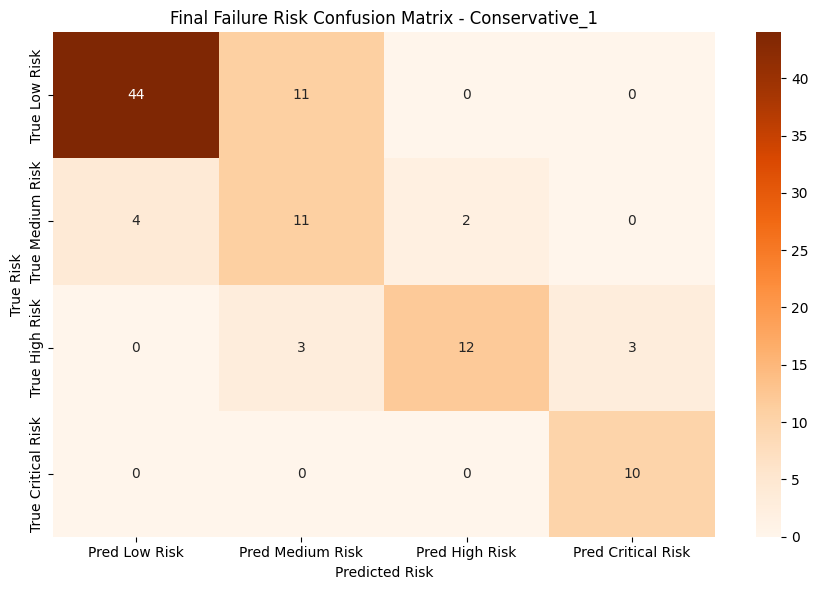

In [62]:
# ============================================================
# 10.8 FINAL CONFUSION MATRIX - CONSERVATIVE_1
# ============================================================

final_risk_cm = confusion_matrix(
    y_true_final,
    y_pred_final,
    labels=risk_order
)

final_risk_cm_df = pd.DataFrame(
    final_risk_cm,
    index=[f"True {label}" for label in risk_order],
    columns=[f"Pred {label}" for label in risk_order]
)

display(final_risk_cm_df)

plt.figure(figsize=(9, 6))

sns.heatmap(
    final_risk_cm_df,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Final Failure Risk Confusion Matrix - Conservative_1")
plt.xlabel("Predicted Risk")
plt.ylabel("True Risk")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "11_final_failure_risk_confusion_matrix_conservative_1.png", dpi=300)
plt.show()

In [63]:
# ============================================================
# 10.9 SAVE FINAL SELECTED THRESHOLDS
# ============================================================

final_thresholds_df = pd.DataFrame({
    "Selected_Strategy": [best_threshold_strategy_name],
    "Critical_Threshold": [best_thresholds["critical"]],
    "High_Threshold": [best_thresholds["high"]],
    "Medium_Threshold": [best_thresholds["medium"]]
})

final_thresholds_df.to_csv(
    PROCESSED_DATA_DIR / "final_business_thresholds.csv",
    index=False
)

final_risk_metrics.to_csv(
    PROCESSED_DATA_DIR / "final_failure_risk_metrics.csv",
    index=False
)

final_risk_cm_df.to_csv(
    PROCESSED_DATA_DIR / "final_failure_risk_confusion_matrix.csv"
)

print("Final thresholds and calibrated risk metrics saved successfully")
display(final_thresholds_df)

Final thresholds and calibrated risk metrics saved successfully


,Selected_Strategy,Critical_Threshold,High_Threshold,Medium_Threshold
0,Conservative_1,20,45,85


# 11. Final Model Export for FastAPI

This section exports all production artifacts required by the FastAPI service.

The API will load these artifacts to:

- receive raw sensor inputs;
- reproduce the same feature engineering pipeline;
- predict Remaining Useful Life;
- classify failure risk;
- assign maintenance priority;
- generate operational recommendations.

In [64]:
# ============================================================
# 11.1 MODEL EXPORT IMPORTS
# ============================================================

import joblib
import json
from datetime import datetime

print("Export libraries imported successfully")

Export libraries imported successfully


In [65]:
# ============================================================
# 11.2 SAVE PRODUCTION ARTIFACTS
# ============================================================

model_artifact_path = MODELS_DIR / "rul_gradient_boosting_model.pkl"
feature_columns_path = MODELS_DIR / "feature_columns.pkl"
engineering_reference_path = MODELS_DIR / "engineering_reference.pkl"
informative_sensors_path = MODELS_DIR / "informative_sensors.pkl"
corr_lookup_path = MODELS_DIR / "correlation_lookup.pkl"
business_thresholds_path = MODELS_DIR / "business_thresholds.pkl"

joblib.dump(best_regression_model, model_artifact_path)
joblib.dump(final_feature_columns, feature_columns_path)
joblib.dump(engineering_reference, engineering_reference_path)
joblib.dump(informative_sensor_features, informative_sensors_path)
joblib.dump(corr_lookup, corr_lookup_path)
joblib.dump(best_thresholds, business_thresholds_path)

print("Production artifacts saved successfully:")
print("-", model_artifact_path)
print("-", feature_columns_path)
print("-", engineering_reference_path)
print("-", informative_sensors_path)
print("-", corr_lookup_path)
print("-", business_thresholds_path)

Production artifacts saved successfully:
- ..\models\rul_gradient_boosting_model.pkl
- ..\models\feature_columns.pkl
- ..\models\engineering_reference.pkl
- ..\models\informative_sensors.pkl
- ..\models\correlation_lookup.pkl
- ..\models\business_thresholds.pkl


In [66]:
# ============================================================
# 11.3 SAVE MODEL METADATA
# ============================================================

model_metadata = {
    "project_name": "SONATRACH Predictive Maintenance API",
    "model_name": "Gradient Boosting Regressor",
    "dataset": "NASA C-MAPSS FD001",
    "target": "RUL_capped",
    "rul_cap": RUL_CAP,
    "final_threshold_strategy": best_threshold_strategy_name,
    "business_thresholds": best_thresholds,
    "number_of_features": len(final_feature_columns),
    "feature_columns": final_feature_columns,
    "validation_mae": float(
        regression_results_df.loc[
            regression_results_df["Model"] == best_regression_model_name,
            "Validation MAE"
        ].values[0]
    ),
    "external_test_last_cycle_mae": float(test_last_mae),
    "external_test_last_cycle_rmse": float(test_last_rmse),
    "external_test_last_cycle_r2": float(test_last_r2),
    "final_risk_accuracy": float(final_accuracy),
    "final_risk_weighted_f1": float(final_f1),
    "export_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

metadata_path = MODELS_DIR / "model_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(model_metadata, file, indent=4)

print("Model metadata saved successfully at:", metadata_path)

display(pd.DataFrame([{
    "Model": model_metadata["model_name"],
    "Validation MAE": model_metadata["validation_mae"],
    "External Test MAE": model_metadata["external_test_last_cycle_mae"],
    "External Test R2": model_metadata["external_test_last_cycle_r2"],
    "Risk Accuracy": model_metadata["final_risk_accuracy"],
    "Risk Weighted F1": model_metadata["final_risk_weighted_f1"],
    "Threshold Strategy": model_metadata["final_threshold_strategy"]
}]))

Model metadata saved successfully at: ..\models\model_metadata.json


,Model,Validation MAE,External Test MAE,External Test R2,Risk Accuracy,Risk Weighted F1,Threshold Strategy
0,Gradient Boosting Regressor,10.483701,11.543262,0.83872,0.77,0.780907,Conservative_1


In [67]:
# ============================================================
# 11.4 VERIFY EXPORTED ARTIFACTS
# ============================================================

exported_files = [
    model_artifact_path,
    feature_columns_path,
    engineering_reference_path,
    informative_sensors_path,
    corr_lookup_path,
    business_thresholds_path,
    metadata_path
]

for file_path in exported_files:
    print(file_path.name, "->", "Exists" if file_path.exists() else "Missing")

rul_gradient_boosting_model.pkl -> Exists
feature_columns.pkl -> Exists
engineering_reference.pkl -> Exists
informative_sensors.pkl -> Exists
correlation_lookup.pkl -> Exists
business_thresholds.pkl -> Exists
model_metadata.json -> Exists


In [68]:
# ============================================================
# 11.5 SAVE HEALTH SCORE REFERENCE
# ============================================================

health_score_reference = {
    "deg_p05": float(deg_p05),
    "deg_p95": float(deg_p95)
}

health_score_reference_path = MODELS_DIR / "health_score_reference.pkl"

joblib.dump(health_score_reference, health_score_reference_path)

print("Health score reference saved successfully:")
print("-", health_score_reference_path)
print("Exists:", health_score_reference_path.exists())

Health score reference saved successfully:
- ..\models\health_score_reference.pkl
Exists: True


# 12. API Test Payload Generation

This section generates realistic JSON payload examples for testing the FastAPI endpoint.

One example is selected for each failure risk level:

- Low Risk;
- Medium Risk;
- High Risk;
- Critical Risk.

These examples will be used in Swagger UI to verify that the API returns meaningful maintenance predictions.

In [69]:
# ============================================================
# 12.1 GENERATE API TEST PAYLOADS FROM REAL TEST ASSETS
# ============================================================

import json

api_input_columns = [
    "time_in_cycles",
    "operational_setting_1",
    "operational_setting_2",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21"
]

risk_order = ["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]

api_test_payloads = {}

for risk_level in risk_order:
    subset = test_last_cycle_data[test_last_cycle_data["failure_risk"] == risk_level].copy()
    
    if len(subset) == 0:
        print(f"No example found for {risk_level}")
        continue
    
    # Select the first available example for each risk level
    row = subset.iloc[0]
    
    payload = {
        "asset_id": f"{risk_level.replace(' ', '_').upper()}_ASSET_{int(row['unit_number'])}"
    }
    
    for col in api_input_columns:
        value = row[col]
        
        if isinstance(value, (np.integer, int)):
            payload[col] = int(value)
        else:
            payload[col] = float(value)
    
    api_test_payloads[risk_level] = payload

print("API test payloads generated successfully")

for risk_level, payload in api_test_payloads.items():
    print("\n" + "=" * 70)
    print(risk_level)
    print("=" * 70)
    print(json.dumps(payload, indent=4))

API test payloads generated successfully

Low Risk
{
    "asset_id": "LOW_RISK_ASSET_1",
    "time_in_cycles": 31,
    "operational_setting_1": -0.0006,
    "operational_setting_2": 0.0004,
    "sensor_2": 642.58,
    "sensor_3": 1581.22,
    "sensor_4": 1398.91,
    "sensor_6": 21.61,
    "sensor_7": 554.42,
    "sensor_8": 2388.08,
    "sensor_9": 9056.4,
    "sensor_11": 47.23,
    "sensor_12": 521.79,
    "sensor_13": 2388.06,
    "sensor_14": 8130.11,
    "sensor_15": 8.4024,
    "sensor_17": 393,
    "sensor_20": 38.81,
    "sensor_21": 23.3552
}

Medium Risk
{
    "asset_id": "MEDIUM_RISK_ASSET_3",
    "time_in_cycles": 126,
    "operational_setting_1": -0.0016,
    "operational_setting_2": 0.0004,
    "sensor_2": 642.88,
    "sensor_3": 1589.75,
    "sensor_4": 1418.89,
    "sensor_6": 21.61,
    "sensor_7": 552.59,
    "sensor_8": 2388.16,
    "sensor_9": 9049.26,
    "sensor_11": 47.88,
    "sensor_12": 520.83,
    "sensor_13": 2388.14,
    "sensor_14": 8131.46,
    "sensor_1

In [70]:
# ============================================================
# 12.2 SAVE API TEST PAYLOADS
# ============================================================

api_payloads_path = PROCESSED_DATA_DIR / "api_test_payloads.json"

with open(api_payloads_path, "w", encoding="utf-8") as file:
    json.dump(api_test_payloads, file, indent=4)

print("API test payloads saved successfully at:", api_payloads_path)

API test payloads saved successfully at: ..\data\processed\api_test_payloads.json


In [71]:
# ============================================================
# 12.3 GENERATE API DEMO PAYLOADS BY PREDICTED RISK
# ============================================================

api_input_columns = [
    "time_in_cycles",
    "operational_setting_1",
    "operational_setting_2",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21"
]

demo_risk_order = ["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]

api_demo_payloads = {}

for risk_level in demo_risk_order:
    subset = risk_predictions[
        risk_predictions["final_predicted_failure_risk"] == risk_level
    ].copy()
    
    if len(subset) == 0:
        print(f"No predicted example found for {risk_level}")
        continue
    
    row = subset.iloc[0]
    
    payload = {
        "asset_id": f"DEMO_{risk_level.replace(' ', '_').upper()}_ASSET_{int(row['unit_number'])}"
    }
    
    for col in api_input_columns:
        value = row[col]
        
        if isinstance(value, (np.integer, int)):
            payload[col] = int(value)
        else:
            payload[col] = float(value)
    
    api_demo_payloads[risk_level] = payload

demo_payloads_path = PROCESSED_DATA_DIR / "api_demo_payloads_by_predicted_risk.json"

with open(demo_payloads_path, "w", encoding="utf-8") as file:
    json.dump(api_demo_payloads, file, indent=4)

print("API demo payloads saved at:", demo_payloads_path)

for risk_level, payload in api_demo_payloads.items():
    print("\n" + "=" * 70)
    print(risk_level)
    print("=" * 70)
    print(json.dumps(payload, indent=4))

API demo payloads saved at: ..\data\processed\api_demo_payloads_by_predicted_risk.json

Low Risk
{
    "asset_id": "DEMO_LOW_RISK_ASSET_1",
    "time_in_cycles": 31,
    "operational_setting_1": -0.0006,
    "operational_setting_2": 0.0004,
    "sensor_2": 642.58,
    "sensor_3": 1581.22,
    "sensor_4": 1398.91,
    "sensor_6": 21.61,
    "sensor_7": 554.42,
    "sensor_8": 2388.08,
    "sensor_9": 9056.4,
    "sensor_11": 47.23,
    "sensor_12": 521.79,
    "sensor_13": 2388.06,
    "sensor_14": 8130.11,
    "sensor_15": 8.4024,
    "sensor_17": 393,
    "sensor_20": 38.81,
    "sensor_21": 23.3552
}

Medium Risk
{
    "asset_id": "DEMO_MEDIUM_RISK_ASSET_3",
    "time_in_cycles": 126,
    "operational_setting_1": -0.0016,
    "operational_setting_2": 0.0004,
    "sensor_2": 642.88,
    "sensor_3": 1589.75,
    "sensor_4": 1418.89,
    "sensor_6": 21.61,
    "sensor_7": 552.59,
    "sensor_8": 2388.16,
    "sensor_9": 9049.26,
    "sensor_11": 47.88,
    "sensor_12": 520.83,
    "sens